# Plotting covariance matrices

This is a notebook in which we can plot the results of our covariance matrix generation, signal-to-noise ratio etc

## Contents<a class="anchor" id="contents"></a>
1. [Packages and useful functions](#util)
1. [Reading in data](#read_data)
    1. [Choosing the dataset](#choose_dataset)
    1. [Reading in distributions](#read_distributions)
    1. [Reading in correlations](#read_correlations)
    1. [Reading in covariance](#read_covariance)
1. [Constructing datasets](#construct_datasets)
    1. [Constructing large matrices](#construct_large_matrices)
    1. [Obtaining the correlations](#obtain_correlations)
1. [Plotting the full covariance matrix](#plot_large_matrix)
1. [Plotting sub-matrices](#plot_sub-matrices)
    1. [Defining useful dictionaries](#useful_dictionaries)
    1. [Code to plot a covariance block](#code_covariance_block)
    1. [Plotting the block](#plot_block)
1. [Signal vs noise](#signal_vs_noise)
    1. [Plot a single graph](#plot_single_graph)
    1. [Plot a grid of graphs](#plot_grid_graph)
    1. [Linear plot with error bars](#linear_plot_error_bars)
    1. [Log-linear plot with ax.fill_between](#semilog_w_fill)
    1. [Signal-to-noise ratio](#SNR)
    1. [Log-linear plot with error bars](#semilog_w_errorbars)
    1. [Log-linear plot with ax.fill_between (plus/minus on same graph)](#semilog_w_fill_pm)
1. [Figures for the theory paper](#figures_theory_paper)
    1. [Optimistic scenario](#optimistic)
    2. [Conservative scenario](#conservative)

## 1. Packages and useful functions<a id='util'></a>
[Back to contents](#contents)

Evaluate this entire section for the next ones to work.

In [1]:
# Load packages
%matplotlib inline
import sys, platform, os
import numpy as np
import itertools
from typing import Dict, Tuple, Any, List, Optional
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict

# Use TeX
from matplotlib import rc
rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

# Path to save figures
#path = 'figures/' # Daniel
path = '/Users/pierrefleury/Nextcloud/Research projects/ELROND/article - Cosmology/figures/' # Pierre's work station
#path = '/Users/pfleury/Nextcloud/Research projects/ELROND/article - Cosmology/figures/' # Pierre's laptop

In [2]:
def load_file(filename):
    """Loads a pickled dictionary"""
    with open(filename, "rb") as f:
        data = pickle.load(f)  # Load the dictionary from the pickle file

    return(data)


def read_correlations(base_folder):

    correlations_data = {}

    LL_file = f'data/{base_folder}/binned_correlations/LL'
    
    try:
        with open(LL_file, "rb") as f:
            correlations_data['LL'] = pickle.load(f)
    except Exception as ex:
        print(f"Error reading LL in {LL_file}: {ex}")

    for corr in ['LE', 'LP']: 

        correlations_data[corr] = []

        if corr == 'LE':
            loop = Nbinz_E
        elif corr == 'LP':
            loop = Nbinz_P
            
        for b1 in range(loop):
            file_name = f'data/{base_folder}/binned_correlations/{corr}{b1}'
            
            try:
                with open(file_name, "rb") as f:
                    correlations_data[corr].append(pickle.load(f))
            except Exception as ex:
                print(f"Error reading {corr} in {file_name}: {ex}")
                
    
    return correlations_data


def read_all_matrices(base_folder):
    """
    Reads ccov, ncov, scov files from each folder in folder_structure,
    now expecting filenames like ccov_0, scov_1_2, etc.
    """
    covariance_data = {}

    for folder in folder_structure:
        folder_path = os.path.join("data", base_folder, "covariance", folder)
        if not os.path.isdir(folder_path):
            print(f"Warning: {folder_path} not found, skipping")
            continue

        # Split into the two 2-letter codes
        comp1, comp2 = folder[:2], folder[2:]
        n1, n2 = Nbinz_map.get(comp1), Nbinz_map.get(comp2)
        if n1 is None or n2 is None:
            print(f"Unknown comp in '{folder}', skipping")
            continue

        # Determine which dimensions vary
        vary1 = (n1 > 0 and comp1 != 'LL')
        vary2 = (n2 > 0 and comp2 != 'LL')

        # Build index tuples and string formatters
        if vary1 and vary2:
            index_iter = itertools.product(range(n1), range(n2))
            fmt = lambda i, j: f"_{i}_{j}"
        elif vary1:
            index_iter = ((i,) for i in range(n1))
            fmt = lambda i: f"_{i}"
        elif vary2:
            index_iter = ((j,) for j in range(n2))
            fmt = lambda j: f"_{j}"
        else:
            index_iter = [()]
            fmt = lambda: ""

        covariance_data[folder] = {name: {} for name in ("ccov", "ncov", "scov")}

        for idx in index_iter:
            idx_str = fmt(*idx)

            for cov_name in ("ccov", "ncov", "scov"):
                fpath = os.path.join(folder_path, f"{cov_name}{idx_str}")
                try:
                    with open(fpath, "rb") as f:
                        mat = pickle.load(f)
                    if mat is not None:
                        covariance_data[folder][cov_name][idx] = mat
                except FileNotFoundError:
                    print(f"{fpath} not found")
                    pass  # Skip missing files without raising
                except Exception as e:
                    print(f"Error reading {fpath}: {e}")

    return covariance_data

In [3]:
def construct_large_matrices(covariance_data):
    """
    Constructs three large covariance matrices (noise, cosmic, sparsity) by arranging
    blocks according to their redshift bin indices and component types.
    
    Notes:
    - Each redshift bin may have different sizes
    - Diagonal blocks determine the row/column dimensions for each bin
    - Off-diagonal blocks must match the dimensions set by diagonal blocks
    - LL has only 1 block (no redshift binning)
    - LE and LP can have arbitrary numbers of redshift bins with arbitrary sizes
    
    Args:
        covariance_data: {
            folder_name: {
                'ncov': { key_tuple: ndarray, ... },
                'ccov': { ... },
                'scov': { ... }
            }, ...
        }
    
    Returns:
        noise_matrix, cosmic_matrix, sparsity_matrix
    """
    
    def parse_folder_name(folder):
        """Extract component types from folder name (e.g., 'LELE' -> ('LE', 'LE'))"""
        return folder[:2], folder[2:]
    
    def analyze_block_structure(covariance_data):
        """
        Analyze the block structure to determine:
        1. Which (component, bin) combinations exist
        2. The size of each (component, bin) combination
        
        The size of each bin is determined from diagonal blocks where possible.
        """
        # Get any covariance type to analyze structure
        sample_cov_type = None
        for folder_data in covariance_data.values():
            for cov_type, blocks in folder_data.items():
                if blocks:
                    sample_cov_type = cov_type
                    break
            if sample_cov_type:
                break
        
        if not sample_cov_type:
            return {}
        
        # Track sizes for each (component, bin) pair
        component_bin_sizes = {}  # {(component, bin): size}
        all_component_bins = set()  # All (component, bin) pairs that exist
        
        # Identify all (component, bin) pairs and their sizes from diagonal blocks
        for folder, matrices in covariance_data.items():
            if sample_cov_type not in matrices:
                continue
            
            row_comp, col_comp = parse_folder_name(folder)
            
            for key, matrix in matrices[sample_cov_type].items():
                if matrix is None:
                    continue
                
                # Determine what (component, bin) pairs this block represents
                if len(key) == 0:  # LLLL case
                    all_component_bins.add(('LL', 0))
                    # For LLLL, both row and col are LL bin 0
                    component_bin_sizes[('LL', 0)] = matrix.shape[0]  # Assuming square
                
                elif len(key) == 1:  # LLLE, LLLP case
                    if row_comp == 'LL':
                        all_component_bins.add(('LL', 0))
                        all_component_bins.add((col_comp, key[0]))
                        component_bin_sizes[('LL', 0)] = matrix.shape[0]
                        component_bin_sizes[(col_comp, key[0])] = matrix.shape[1]
                    elif col_comp == 'LL':
                        all_component_bins.add((row_comp, key[0]))
                        all_component_bins.add(('LL', 0))
                        component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                        component_bin_sizes[('LL', 0)] = matrix.shape[1]
                    else:
                        # Both components vary, diagonal block
                        all_component_bins.add((row_comp, key[0]))
                        all_component_bins.add((col_comp, key[0]))
                        if row_comp == col_comp:  # True diagonal
                            component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                        else:
                            component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                            component_bin_sizes[(col_comp, key[0])] = matrix.shape[1]
                
                elif len(key) == 2:  # LELE, LPLP, LELP case
                    all_component_bins.add((row_comp, key[0]))
                    all_component_bins.add((col_comp, key[1]))
                    
                    # For diagonal blocks, we can determine the size
                    if row_comp == col_comp and key[0] == key[1]:
                        component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                    else:
                        # Off-diagonal: sizes should be consistent with diagonal blocks
                        if (row_comp, key[0]) not in component_bin_sizes:
                            component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                        if (col_comp, key[1]) not in component_bin_sizes:
                            component_bin_sizes[(col_comp, key[1])] = matrix.shape[1]
        
        # Organize by component
        component_info = defaultdict(lambda: {'bins': [], 'sizes': {}})
        
        for (comp, bin_idx), size in component_bin_sizes.items():
            component_info[comp]['bins'].append(bin_idx)
            component_info[comp]['sizes'][bin_idx] = size
        
        # Sort bins and remove duplicates
        for comp in component_info:
            component_info[comp]['bins'] = sorted(set(component_info[comp]['bins']))
        
        return dict(component_info)
    
    
    def create_single_matrix(cov_type):
        """Create a single large matrix for the given covariance type."""
        
        # Step 1: Analyze block structure
        component_info = analyze_block_structure(covariance_data)
        
        if not component_info:
            print(f"No component info found for {cov_type}")
            return None
        
        # print(f"Component analysis for {cov_type}:")
        for comp in ['LL', 'LP', 'LE']:
            if comp in component_info:
                info = component_info[comp]
                # print(f"  {comp}: bins {info['bins']}")
                for bin_idx in info['bins']:
                    size = info['sizes'].get(bin_idx, 'unknown')
                    # print(f"    bin {bin_idx}: size {size}")
        
        # Step 2: Calculate offsets for each (component, bin) pair
        offsets = {}  # {(component, bin): offset}
        total_size = 0
        
        for comp in ['LL', 'LP', 'LE']:
            if comp in component_info:
                info = component_info[comp]
                for bin_idx in info['bins']:
                    offsets[(comp, bin_idx)] = total_size
                    bin_size = info['sizes'][bin_idx]
                    total_size += bin_size
        
        # Step 3: Create the large matrix
        large_matrix = np.zeros((total_size, total_size))
        
        # Step 4: Place all blocks
        for folder, matrices in covariance_data.items():
            if cov_type not in matrices or not matrices[cov_type]:
                continue
            
            row_comp, col_comp = parse_folder_name(folder)
            
            for key, matrix in matrices[cov_type].items():
                if matrix is None:
                    continue
                
                # Determine the (component, bin) pairs for this block
                row_comp_bins, col_comp_bins = determine_component_bins(folder, key)
                
                # Place the block for each combination
                for (r_comp, r_bin) in row_comp_bins:
                    for (c_comp, c_bin) in col_comp_bins:
                        
                        # Get offsets
                        row_offset = offsets.get((r_comp, r_bin))
                        col_offset = offsets.get((c_comp, c_bin))
                        
                        if row_offset is None or col_offset is None:
                            print(f"WARNING: Missing offset for ({r_comp}, {r_bin}) or ({c_comp}, {c_bin})")
                            continue
                        
                        # Get expected sizes
                        expected_row_size = component_info[r_comp]['sizes'][r_bin]
                        expected_col_size = component_info[c_comp]['sizes'][c_bin]
                        
                        # Verify matrix dimensions
                        if matrix.shape != (expected_row_size, expected_col_size):
                            print(f"WARNING: Block {folder}[{key}] has shape {matrix.shape}, "
                                  f"expected ({expected_row_size}, {expected_col_size}) for "
                                  f"({r_comp},{r_bin}) × ({c_comp},{c_bin})")
                            continue
                        
                        # Place the block
                        row_start = row_offset
                        row_end = row_start + expected_row_size
                        col_start = col_offset
                        col_end = col_start + expected_col_size
                        
                        large_matrix[row_start:row_end, col_start:col_end] += matrix
                        
                        # Handle transpose for cross-component blocks
                        if should_place_transpose(folder, r_comp, c_comp, r_bin, c_bin):
                            # Transpose: swap row and column components/bins
                            t_row_offset = offsets[(c_comp, c_bin)]
                            t_col_offset = offsets[(r_comp, r_bin)]
                            
                            t_row_start = t_row_offset
                            t_row_end = t_row_start + expected_col_size
                            t_col_start = t_col_offset
                            t_col_end = t_col_start + expected_row_size
                            
                            large_matrix[t_row_start:t_row_end, t_col_start:t_col_end] += matrix.T
        
        return large_matrix
    
    def determine_component_bins(folder, key):
        """
        Determine which (component, bin) pairs a block represents.
        
        Returns: (row_component_bins, col_component_bins)
        Each is a list of (component, bin) tuples.
        """
        row_comp, col_comp = parse_folder_name(folder)
        
        if len(key) == 0:  # LLLL case
            return [('LL', 0)], [('LL', 0)]
        
        elif len(key) == 1:  # LLLE, LLLP case
            if row_comp == 'LL' and col_comp != 'LL':
                return [('LL', 0)], [(col_comp, key[0])]
            elif row_comp != 'LL' and col_comp == 'LL':
                return [(row_comp, key[0])], [('LL', 0)]
            else:
                # Both components vary - diagonal block
                return [(row_comp, key[0])], [(col_comp, key[0])]
        
        elif len(key) == 2:  # LELE, LPLP, LELP case
            return [(row_comp, key[0])], [(col_comp, key[1])]
        
        else:
            raise ValueError(f"Unexpected key length: {key}")
    
    def should_place_transpose(folder: str, row_comp: str, col_comp: str, 
                             row_bin: int, col_bin: int) -> bool:
        """
        Determine if we should place the transpose of this block.
        Only for off-diagonal component blocks.
        """
        # Only transpose cross-component blocks
        if row_comp == col_comp:
            return False
        
        # Only transpose certain folder types that represent symmetric relationships
        if folder not in ['LLLE', 'LLLP', 'LELP']:
            return False
        
        return True
    
    # Create each matrix type
    noise_matrix = create_single_matrix('ncov')
    cosmic_matrix = create_single_matrix('ccov')
    sparsity_matrix = create_single_matrix('scov')
    
    return noise_matrix, cosmic_matrix, sparsity_matrix

In [4]:
def format_sci(n):
    # Convert the number to scientific notation with 1 decimal place
    scientific_notation = "{:.1e}".format(n)

    # Split the mantissa and the exponent
    mantisse, exponent = scientific_notation.split('e')
    exponent = int(exponent)

    # Format the LaTeX string
    if exponent == 0:
        # If the exponent is 0, display only the mantissa
        latex_string = rf"${mantisse}$"
    else:
        # Otherwise, display the full scientific notation
        latex_string = rf"${mantisse} \times 10^{{{exponent}}}$"

    return latex_string


def find_block_idx(i):
    """
    Finds the block number of a cell in the matrix and the number of angular bins.
    Block 0 = LL minus
    Block 1 = LL plus
    Block 2..2+Nbinz_P-1 = LP redshift bins
    Block 2+Nbinz_P.. = LE redshift bins (split into minus/plus)
    """
    # LL block (block 0 and 1)
    ll_minus = angular_bin_dictionary_pm['LL']['minus'][0]
    ll_plus  = angular_bin_dictionary_pm['LL']['plus'][0]
    
    if i < ll_minus:
        return 0, ll_minus
    elif i < ll_minus + ll_plus:
        return 1, ll_plus

    offset = ll_minus + ll_plus

    # LP blocks (block 2 .. 2+Nbinz_P-1)
    for b in range(Nbinz_P):
        bins = angular_bin_dictionary['LP'][b]
        if i < offset + bins:
            return 2 + b, bins
        offset += bins

    # LE blocks (block 2+Nbinz_P .. )
    for b in range(Nbinz_E):
        minus_bins = angular_bin_dictionary_pm['LE']['minus'][b]
        plus_bins  = angular_bin_dictionary_pm['LE']['plus'][b]
        
        if i < offset + minus_bins:
            return 2 + Nbinz_P + b * 2, minus_bins
        offset += minus_bins

        if i < offset + plus_bins:
            return 2 + Nbinz_P + b * 2 + 1, plus_bins
        offset += plus_bins

    raise ValueError(f"Index {i} is out of bounds in total angular bin configuration.")

In [17]:
def plot_covariance(covariance_data, correlations_data,
                    plot_colours=True, 
                    scale=True,
                    normalize=True,
                    log_scale=True,
                    plot_noise=True,
                    plot_cosmic=True,
                    plot_sparsity=True,
                    redshift_binning=True,
                    figsize=(12, 10),
                    eps=1e-6,
                    gamma=1,
                    eta=1,
                    verbose=False
                   ):
    """
    Plots a covariance matrix
    
    Args:
        covariance_data: Dictionary containing ncov, ccov, and scov matrices
        correlations_data: The LL, LE and LP correlation functions
        plot_colours: if True, break components into RGB, if False, plot total covariance
        scale: scale the matrix by the corresponding correlations
        normalize: Whether to normalize the color intensities
        log_scale: Whether to use log scale for color intensities
        plot_noise, plot_cosmic, plot_sparsity: whether to include these sources of covariance
        figsize: Size of the figure (width, height)
        eps:higher numbers = higher contrast
        gamma: <1 brightens darks, >1 darkens
        eta: >1 oversaturates, <1 undersaturates
    """
    
    # Get the three matrices
    noise, cosmic, sparsity = construct_large_matrices(covariance_data)

    noise_mat = noise.copy()
    cosmic_mat = cosmic.copy()
    sparsity_mat = sparsity.copy()
    
    
    # Get the correlation list
    correlations_list = []

    # add LL- and LL+
    correlations_list.extend(correlations_data['LL']['minus_correlation'])
    correlations_list.extend(correlations_data['LL']['plus_correlation'])

    # add LP for each redshift bins
    for B in range(Nbinz_P):
        correlations_list.extend(correlations_data['LP'][B]['correlation'])

    # add LE- and LE+ for each redshift bin
    for B in range(Nbinz_E):
        correlations_list.extend(correlations_data['LE'][B]['minus_correlation'])
        correlations_list.extend(correlations_data['LE'][B]['plus_correlation'])

    side_length = len(correlations_list)
    
    
    #here, we scale our matrices by the corresponding product of correlations. Thus we have an indication of SNR
    if scale:
        
        # rescale the covmats
        noise_mat /= np.outer(correlations_list, correlations_list)
        cosmic_mat /= np.outer(correlations_list, correlations_list)
        sparsity_mat /= np.outer(correlations_list, correlations_list)
        
        if verbose:
            print('max(|NCov|/signal^2) = {}'.format(np.max(np.abs(noise_mat))))
            print('max(|SCov|/signal^2) = {}'.format(np.max(np.abs(sparsity_mat))))
            print('max(|CCov|/signal^2) = {}'.format(np.max(np.abs(cosmic_mat))))
            
            # find indices for which Cov > signal^2
            indices_large_cov = np.where(
                                        (np.abs(noise_mat)>1)|
                                        (np.abs(cosmic_mat)>1)|
                                        (np.abs(sparsity_mat)>1)
                                        )
            print("""
            Indices for which Cov > signal^2:
            """, np.transpose(indices_large_cov))
            
            print('max(|NVar|/signal^2) = {}'.format(np.max(np.abs(noise_mat.diagonal()))))
            print('max(|SVar|/signal^2) = {}'.format(np.max(np.abs(sparsity_mat.diagonal()))))
            print('max(|CVar|/signal^2) = {}'.format(np.max(np.abs(cosmic_mat.diagonal()))))
            
            # find indices for which SNR < 1
            indices_low_SNR = np.where(
                                        (np.abs(noise_mat.diagonal())>1)|
                                        (np.abs(cosmic_mat.diagonal())>1)|
                                        (np.abs(sparsity_mat.diagonal())>1)
                                        )
            print("""
            Indices for which SNR < 1:
            """, indices_low_SNR)
            

    if plot_colours:

        #here, we keep only the absolute values (for plotting)
        noise_mat = np.abs(noise_mat)
        cosmic_mat = np.abs(cosmic_mat)
        sparsity_mat = np.abs(sparsity_mat)

        max_value = max(np.max(noise_mat), np.max(cosmic_mat), np.max(sparsity_mat))
        true_min = min(np.min(noise_mat), np.min(cosmic_mat), np.min(sparsity_mat))
        true_max = max_value
        half_value = np.sqrt(true_max)
        
        # Apply log scale if required (np.log1p(x) is log(1+x))
        if log_scale:
            noise_mat = np.log1p(noise_mat/eps)
            cosmic_mat = np.log1p(cosmic_mat/eps)
            sparsity_mat = np.log1p(sparsity_mat/eps)
            half_value = np.sqrt(true_max * eps)
            
        noise_mat **= gamma
        cosmic_mat **= gamma
        sparsity_mat **= gamma 
        
        max_val = max(np.max(noise_mat), np.max(cosmic_mat), np.max(sparsity_mat)) / eta
        
        #here, we normalise our matrices by the maximum value
        if normalize:        
            if max_val > 0:
                noise_mat /= max_val
                cosmic_mat /= max_val
                sparsity_mat /= max_val
                
        min_val = min(np.min(noise_mat),np.min(cosmic_mat),np.min(sparsity_mat))

        #min_colourbar = min_val/max_val
        min_colourbar = 0
        max_colourbar = 1
        mid_colourbar = (max_colourbar+min_colourbar)/2
        
        # Create RGB array
        rgb_matrix = np.zeros(noise_mat.shape + (3,))
        if plot_noise:
            rgb_matrix[..., 1] = noise_mat  # Green for noise
        if plot_cosmic:
            rgb_matrix[..., 0] = cosmic_mat  # Red for cosmic
        if plot_sparsity:
            rgb_matrix[..., 2] = sparsity_mat  # Blue for sparsity
            
        if verbose:
            # Indicate in yellow the points with large Cov
            rgb_matrix[indices_large_cov] = [1, 1, 0]
        
        # Create the plot
        fig, ax = plt.subplots(figsize=figsize)
        N = rgb_matrix.shape[0]
        im = ax.imshow(rgb_matrix, aspect='equal', extent=[-0.5, N-0.5, N-0.5, -0.5])

    else:

        # Build total matrix
        total_mat = np.zeros_like(noise_mat)
        if plot_noise:
            total_mat += noise_mat
        if plot_cosmic:
            total_mat += cosmic_mat
        if plot_sparsity:
            total_mat += sparsity_mat

        total_mat = np.abs(total_mat)
    
        # --- Determine dynamic range ---
        true_max = np.max(total_mat)
        half_value = np.sqrt(true_max)
        true_min = np.min(total_mat)
    
        # --- Log scaling ---
        if log_scale:
            total_mat = np.log1p(total_mat / eps)
            half_value = np.sqrt(true_max * eps)
    
        # --- Gamma correction ---
        total_mat **= gamma
    
        # --- Normalization ---
        if normalize:
            max_val = np.max(total_mat) / eta
            if max_val > 0:
                total_mat /= max_val

        #min_colourbar = np.min(total_mat)/np.max(total_mat)
        min_colourbar = 0
        max_colourbar = 1
        mid_colourbar = (max_colourbar+min_colourbar)/2
    
        # --- Plot setup ---
        fig, ax = plt.subplots(figsize=figsize)
        N = total_mat.shape[0]
        vmin = np.min(total_mat)
        vmax = np.max(total_mat)
        im = ax.imshow(
            total_mat,
            aspect='equal',
            extent=[-0.5, N-0.5, N-0.5, -0.5],
            cmap='inferno',
            vmin=vmin,
            vmax=vmax,
        )
    
    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    # For example: vertical lines after columns 2, 5, and 7
    x_lines = [angular_bin_dictionary['LL'][0], angular_bin_dictionary['LL'][0]+ np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)])]
    
    # Shift by -0.5 to align with imshow cell edges
    x_minor = [x - 0.5 for x in x_lines]
    
    # Set minor ticks only at those specific positions
    ax.set_xticks(x_minor, minor=True)
    ax.set_yticks(x_minor, minor=True)

    # Draw gridlines only at those positions
    ax.grid(which='minor', color='w', linestyle='-', linewidth=1)

    # Get matrix size to determine label positioning
    matrix_size = noise_mat.shape[0]      #this gives the number of cells on an axis 
    
    # Create custom tick positions and labels
    inner_labels = []
    # LL once
    inner_labels.extend(range(1, angular_bin_dictionary_pm['LL']['minus'][0] + 1))
    inner_labels.extend(range(1, angular_bin_dictionary_pm['LL']['plus'][0] + 1))
    # LP repeated Nbinz_P times
    for b in range(Nbinz_P):
        inner_labels.extend(range(1, angular_bin_dictionary['LP'][b] + 1))
    # LE repeated 2*Nbinz_E times
    for b in range(Nbinz_E):
        inner_labels.extend(range(1, angular_bin_dictionary_pm['LE']['minus'][b] + 1))
        inner_labels.extend(range(1, angular_bin_dictionary_pm['LE']['plus'][b] + 1))

    inner_ticks = np.arange(len(inner_labels))
    
    # Create the figure with reduced distance between plot and colorbars
    # Adjust right margin to be closer to the plot
    plt.subplots_adjust(right=0.85)

    if plot_colours:
    
        # Create separate colorbars closer to the plot
        cbar_ax1 = fig.add_axes([0.87, 0.7, 0.02, 0.2])  # Red (cosmic)
        cbar_ax2 = fig.add_axes([0.87, 0.4, 0.02, 0.2])  # Green (noise)
        cbar_ax3 = fig.add_axes([0.87, 0.1, 0.02, 0.2])  # Blue (sparsity)
        
        # Define color maps
        red_cmap = plt.cm.Reds_r
        green_cmap = plt.cm.Greens_r
        blue_cmap = plt.cm.Blues_r
        
        # Create ScalarMappables
        norm = plt.Normalize(vmin=0, vmax=1)
        sm_red = plt.cm.ScalarMappable(cmap=red_cmap, norm=norm)
        sm_green = plt.cm.ScalarMappable(cmap=green_cmap, norm=norm)
        sm_blue = plt.cm.ScalarMappable(cmap=blue_cmap, norm=norm)
        
        # Add colorbars
        cbar1 = plt.colorbar(sm_red, cax=cbar_ax1)
        cbar2 = plt.colorbar(sm_green, cax=cbar_ax2)
        cbar3 = plt.colorbar(sm_blue, cax=cbar_ax3)
        
        cbar1.set_label(r"cosmic", color='red',fontsize=30)
        cbar2.set_label(r"noise", color='green',fontsize=30)
        cbar3.set_label(r"sparsity", color='blue',fontsize=30)
        
        cbar1.set_ticks([min_colourbar, mid_colourbar, max_colourbar])
        cbar2.set_ticks([min_colourbar, mid_colourbar, max_colourbar])
        cbar3.set_ticks([min_colourbar, mid_colourbar, max_colourbar])
            
        # 
        tick_positions1 = cbar1.get_ticks()
        tick_positions2 = cbar2.get_ticks()
        tick_positions3 = cbar3.get_ticks()
    
        # --- Convert normalized positions back to data values
        if hasattr(norm, "inverse"):
            tick_values1 = norm.inverse(tick_positions1)
            tick_values2 = norm.inverse(tick_positions2)
            tick_values3 = norm.inverse(tick_positions3)
        else:
            tick_values1 = norm.vmin + tick_positions1 * (norm.vmax - norm.vmin)
            tick_values2 = norm.vmin + tick_positions2 * (norm.vmax - norm.vmin)
            tick_values3 = norm.vmin + tick_positions3 * (norm.vmax - norm.vmin)
    
        # --- Apply your transforms in *data space*
        if normalize and max_val > 0:
            tick_values1 *= max_val
            tick_values2 *= max_val
            tick_values3 *= max_val

        tick_values1 **= 1/gamma
        tick_values2 **= 1/gamma
        tick_values3 **= 1/gamma
        
        if log_scale:
            tick_values1 = eps * np.expm1(tick_values1)
            tick_values2 = eps * np.expm1(tick_values2)
            tick_values3 = eps * np.expm1(tick_values3)
    
        # --- Set the ticks and their labels
        cbar1.set_ticklabels([format_sci(v) for v in tick_values1],fontsize=25)
        cbar2.set_ticklabels([format_sci(v) for v in tick_values2],fontsize=25)
        cbar3.set_ticklabels([format_sci(v) for v in tick_values3],fontsize=25)

    else:

        # --- Colorbar for total intensity ---
        norm = plt.Normalize(vmin=0, vmax=1)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Total covariance (summed)", fontsize=25)
        cbar.set_ticks([min_colourbar, mid_colourbar, max_colourbar])
    
        # 
        tick_positions = cbar.get_ticks()
    
        # --- Convert normalized positions back to data values
        if hasattr(norm, "inverse"):
            tick_values = norm.inverse(tick_positions)
        else:
            tick_values = norm.vmin + tick_positions * (norm.vmax - norm.vmin)
    
        # --- Apply your transforms in *data space*
        if normalize and max_val > 0:
            tick_values *= max_val

        tick_values **= 1/gamma
        
        if log_scale:
            tick_values = eps * np.expm1(tick_values)
    
        # --- Set the ticks and their labels
        cbar.set_ticks(tick_positions)
        cbar.set_ticklabels([format_sci(v) for v in tick_values])

    # Add first level (innermost) labels
    ax.set_xticks(inner_ticks)
    ax.set_yticks(inner_ticks)
    ax.set_xticklabels(inner_labels, fontsize= 5 * 75/side_length)
    ax.set_yticklabels(inner_labels, fontsize= 5 * 75/side_length, rotation = 90)
    
    # Define label positions with evenly spaced tiers
    # We need to ensure enough space for the additional tiers of labels
    plt.subplots_adjust(left=0.12, top=0.85, bottom=0.05)
    
    # Define evenly spaced offsets for the different tiers of labels
    # offset_unit = matrix_size / 30  # Tune this divisor to space things properly
    offset_unit = 3 * side_length / 81  # Tune this to space things properly
    if redshift_binning:
        middle_tier_offset = -0.8 * offset_unit
    else:
        middle_tier_offset = -1.4 * offset_unit
    outer_tier_offset = -1.4 * offset_unit
    extra_tier_offset = -2.3 * offset_unit
    
    # Middle tier: +/- labels
    # "-" for first block of Nbina, "+" for next, nothing for next Nbin_z blocks, alternating -/+ for last 2*Nbin_z blocks
    middle_labels = []
    for i in range(matrix_size):       #looping through the blocks
        block_idx, Na = find_block_idx(i)
        if block_idx == 0:
            middle_labels.append(r'$-$')
        elif block_idx == 1:
            middle_labels.append(r'$+$')
        elif block_idx < Nbinz_P+2:  # blocks 2 to (Nbinz_P + 1) (Nbinz_P blocks)
            middle_labels.append('')
        else:  # blocks (Nbinz_P + 2) to (Nbinz_E + Nbinz_P + 2) (Nbinz_E blocks)
            if (block_idx - (Nbinz_P+2)) % 2 == 0:
                middle_labels.append(r'$-$')
            else:
                middle_labels.append(r'$+$')
    
    # Function to add section label
    def add_section_label(pos, label, offset, fontsize, is_x_axis=True):
        new_offset = offset
        # if label == r'$-$':
        #     new_offset = offset - 0.12 * fontsize
        # else:
        #     new_offset = offset
        if label and is_x_axis:
            ax.text(pos, new_offset, label, ha='center', va='center', fontsize=fontsize)
        if label and not is_x_axis:
            ax.text(new_offset, pos, label, ha='center', va='center', fontsize=fontsize, rotation=90)
    
    # Add middle tier labels (-/+) - with spacing adjustment to avoid overlap
    checklist = []
    for i in range(0, matrix_size):  
        block_idx, Na = find_block_idx(i)
        if block_idx in checklist:
            continue
        else:
            checklist.append(block_idx)
            if middle_labels[i]:
                # Only add label once per block
                add_section_label(i + Na / 2 -0.5, middle_labels[i], middle_tier_offset, 10, True)
                add_section_label(i + Na / 2 -0.5, middle_labels[i], middle_tier_offset, 10, False)
            
    # Add outer tier labels (numbers)
    # Nothing for first 2 blocks
    # 1 to Nbinz_P for next Nbinz_P blocks (blocks 2 to Nbinz_P + 2)
    if redshift_binning:
        for block_idx in range(2, Nbinz_P+2):
            center_pos = angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(block_idx-2)]) + angular_bin_dictionary['LP'][block_idx-2] / 2.5 
            add_section_label(center_pos, r"$B = {}$" + str(block_idx-1), outer_tier_offset, 5 * np.sqrt(angular_bin_dictionary['LP'][block_idx-2] / 5), True)
            add_section_label(center_pos, r"$D = {}$" + str(block_idx-1), outer_tier_offset, 5 * np.sqrt(angular_bin_dictionary['LP'][block_idx-2] / 5), False)

        # 0-Nbinz_E for last 2*Nbinz_E blocks (1 label per 2 blocks)
        for block_idx in range(0, Nbinz_E):
            # Position at the center of each pair of blocks
            center_pos = np.sum([angular_bin_dictionary['LE'][b] for b in range(block_idx)]) + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) + angular_bin_dictionary['LL'][0] + angular_bin_dictionary['LE'][block_idx] / 2.5
            add_section_label(center_pos, r"$B = {}$" + str(block_idx+1), outer_tier_offset, 5 * np.sqrt(angular_bin_dictionary['LE'][block_idx] / 5), True)
            add_section_label(center_pos, r"$D = {}$" + str(block_idx+1), outer_tier_offset, 5 * np.sqrt(angular_bin_dictionary['LE'][block_idx]  / 5), False)
    
    # Add extra tier labels (LL, LP, LE) - only once per section
    # LL (first 2 blocks)
    add_section_label(angular_bin_dictionary['LL'][0] / 2.1, r'$(\mathrm{LL})^\pm_\alpha$', extra_tier_offset, 22, True)
    add_section_label(angular_bin_dictionary['LL'][0] / 2.1, r'$(\mathrm{LL})^\pm_\beta$', extra_tier_offset, 22, False)
    
    if redshift_binning:
        # LP (next Nbinz_P blocks)
        add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) / 2.1, r'$(\mathrm{L}^+\mathrm{P}_B)_\alpha$', extra_tier_offset, 22, True)
        add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) / 2.1, r'$(\mathrm{L}^+\mathrm{P}_D)_\beta$', extra_tier_offset, 22, False)

        # LE (last 2*Nbinz_E blocks)
        add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) + np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)]) / 2.1, r'$(\mathrm{L}\mathrm{E}_B)^\pm_\alpha$', extra_tier_offset, 22, True)
        add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) + np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)]) / 2.1, r'$(\mathrm{L}\mathrm{E}_D)^\pm_\beta$', extra_tier_offset, 22, False)
    else:
        # LP (next Nbinz_P blocks)
        add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) / 2.1, r'$(\mathrm{L}^+\mathrm{P})_\alpha$', extra_tier_offset, 22, True)
        add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) / 2.1, r'$(\mathrm{L}^+\mathrm{P})_\beta$', extra_tier_offset, 22, False)

        # LE (last 2*Nbinz_E blocks)
        add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) + np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)]) / 2.1, r'$(\mathrm{L}\mathrm{E})^\pm_\alpha$', extra_tier_offset, 22, True)
        add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) + np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)]) / 2.1, r'$(\mathrm{L}\mathrm{E})^\pm_\beta$', extra_tier_offset, 22, False)
        
    
    return fig

In [6]:
def plot_double_covariance(
    covariance_data, correlations_list,
    scale=True, normalize=True, variance_scale=True, 
    log_scale=True, plot_noise=True, plot_cosmic=True, plot_sparsity=True,
    figsize=(24, 10), eps=1e-6, gamma=1, eta=1,
    titles=("Left covariance", "Right covariance")
):
    """
    Plots two covariance matrices, side by side for comparison. 
    Option to rescale by correlations or variance
    Args:
        covariance_data: Dictionary containing ncov, ccov, and scov matrices
        correlations_list: The LL, LE and LP correlation functions
        scale: if True, the matrix will be rescaled by the correlation functions
        normalize: Whether to normalize the color intensities
        log_scale: Whether to use log scale for color intensities
        plot_noise, plot_cosmic, plot_sparsity: whether to include these sources of covariance
        figsize: Size of the figure (width, height)
        eps:higher numbers = higher contrast
        gamma: <1 brightens darks, >1 darkens
        eta: >1 oversaturates, <1 undersaturates
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    plt.subplots_adjust(wspace=0.40)  # spacing between subplots
       
    # Get the three covariance matrices
    noise, cosmic, sparsity = construct_large_matrices(covariance_data)

    #a function for plotting each of the two side-by-side matrices individually
    def _plot_single(ax, method):

        ########### Data adjustments ############

        if method == 'colours':
            
            #copies of these matrices, so our adjustments don't affect the originals
            noise_mat = noise.copy()
            cosmic_mat = cosmic.copy()
            sparsity_mat = sparsity.copy()
            
            if scale:
                #rescale everything by the correlations
                noise_mat /= np.outer(correlations_list, correlations_list)
                cosmic_mat /= np.outer(correlations_list, correlations_list)
                sparsity_mat /= np.outer(correlations_list, correlations_list)

            #keep only absolute values        
            noise_mat = np.abs(noise_mat)
            cosmic_mat = np.abs(cosmic_mat)
            sparsity_mat = np.abs(sparsity_mat)
            
            #change to log scale (log(1+x))
            if log_scale:
                noise_mat = np.log1p(noise_mat / eps)
                cosmic_mat = np.log1p(cosmic_mat / eps)
                sparsity_mat = np.log1p(sparsity_mat / eps)
            
            #gamma scaling        
            noise_mat **= gamma
            cosmic_mat **= gamma
            sparsity_mat **= gamma
            
            max_val = max(np.max(noise_mat), np.max(cosmic_mat), np.max(sparsity_mat)) / eta
            
            #normalise matrices by the maximum value
            if normalize:
                if max_val > 0:
                    noise_mat /= max_val
                    cosmic_mat /= max_val
                    sparsity_mat /= max_val
            
            min_val = min(np.min(noise_mat),np.min(cosmic_mat),np.min(sparsity_mat))

            #defining the points of the colourbar (to label them properly)
            min_colourbar = min_val/max_val
            max_colourbar = 1
            mid_colourbar = (max_colourbar+min_colourbar)/2
        
            #create RGB array
            rgb_matrix = np.zeros(noise_mat.shape + (3,))
            if plot_noise:
                rgb_matrix[..., 1] = noise_mat # Green for noise
            if plot_cosmic:
                rgb_matrix[..., 0] = cosmic_mat # Red for cosmic
            if plot_sparsity:
                rgb_matrix[..., 2] = sparsity_mat #Blue for sparsity
    
            #create the plot
            N = rgb_matrix.shape[0]
            ax.set_aspect('equal', adjustable='box')
            ax.imshow(rgb_matrix, aspect='equal', extent=[-0.5, N-0.5, N-0.5, -0.5])
                

        else:

            # Build total matrix
            total_mat = np.zeros_like(noise)
            
            if plot_noise:
                total_mat += noise
            if plot_cosmic:
                total_mat += cosmic
            if plot_sparsity:
                total_mat += sparsity
            
            if scale:
                #rescale by correlations
                total_mat /= np.outer(correlations_list, correlations_list)

            total_mat = np.abs(total_mat)
            
            # log scaling
            if log_scale:
                total_mat = np.log1p(total_mat / eps)
        
            # gamma correction
            total_mat **= gamma
        
            # normalisation
            if normalize:
                max_val = np.max(total_mat) / eta
                if max_val > 0:
                    total_mat /= max_val

            min_colourbar = np.min(total_mat)/np.max(total_mat)
            max_colourbar = 1
            mid_colourbar = (max_colourbar+min_colourbar)/2
        
            # Plot setup 
            N = total_mat.shape[0]
            vmin = np.min(total_mat)
            vmax = np.max(total_mat)
            ax.set_aspect('equal', adjustable='box')
            
            #produce the figure
            im = ax.imshow(
                total_mat,
                aspect='equal',
                extent=[-0.5, N-0.5, N-0.5, -0.5],
                cmap='inferno',
                vmin=vmin,
                vmax=vmax,
            )
        
        ################ ticks, labelling, colourbars etc ####################

        #move x-axis labels to the top    
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')

        # grid boundaries 
        x_lines = [
            angular_bin_dictionary['LL'][0],
            angular_bin_dictionary['LL'][0]
            + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)])
        ]
        
        #shift to align with the cell edges
        x_minor = [x - 0.5 for x in x_lines]
        
        #set minor ticks only at those specific positions
        ax.set_xticks(x_minor, minor=True)
        ax.set_yticks(x_minor, minor=True)

        #draw gridlines only at those positions
        ax.grid(which='minor', color='w', linestyle='-', linewidth=1)

        #get matrix size to determine label positioning
        matrix_size = noise.shape[0]
        
        ####### Inner, numerical labels #########
        
        ##LL once
        inner_labels = []
        inner_labels.extend(range(1, angular_bin_dictionary_pm['LL']['minus'][0] + 1))
        inner_labels.extend(range(1, angular_bin_dictionary_pm['LL']['plus'][0] + 1))
        #LP repeated Nbinz_P times
        for b in range(Nbinz_P):
            inner_labels.extend(range(1, angular_bin_dictionary['LP'][b] + 1))
        #LE repeated 2*Nbinz_E times
        for b in range(Nbinz_E):
            inner_labels.extend(range(1, angular_bin_dictionary_pm['LE']['minus'][b] + 1))
            inner_labels.extend(range(1, angular_bin_dictionary_pm['LE']['plus'][b] + 1))
        
        inner_ticks = np.arange(len(inner_labels))
        
        #add first level (innermost) labels
        ax.set_xticks(inner_ticks)
        ax.set_yticks(inner_ticks)
        ax.set_xticklabels(inner_labels, fontsize=5 * 75 / side_length)
        ax.set_yticklabels(inner_labels, fontsize=5 * 75 / side_length, rotation=90)
        
        ####### Other labels #########

        # Define label positions with evenly spaced tiers
        #we need to ensure enough space for the additional tiers of labels
        plt.subplots_adjust(left=0.12, top=0.85, bottom=0.05)
        offset_unit = 3 * side_length / 81
        middle_tier_offset = -1.2 * offset_unit   #plus and minus signs
        outer_tier_offset = -2.2 * offset_unit    #redshift bins
        extra_tier_offset = -3.5 * offset_unit    #correlation label

        #a function to place these additional labels
        def add_section_label(pos, label, offset, fontsize, is_x_axis=True):
            offset
            if label and is_x_axis:
                ax.text(pos, offset, label, ha='center', va='center', fontsize=fontsize)
            if label and not is_x_axis:
                ax.text(offset, pos, label, ha='center', va='center', fontsize=fontsize, rotation=90)

        #adding the plus minus where appropriate
        middle_labels = []
        for i in range(matrix_size):
            block_idx, Na = find_block_idx(i)
            if block_idx == 0:
                middle_labels.append(r'$-$')
            elif block_idx == 1:
                middle_labels.append(r'$+$')
            elif block_idx < Nbinz_P + 2:
                middle_labels.append('')
            else:
                middle_labels.append(r'$-$' if (block_idx - (Nbinz_P + 2)) % 2 == 0 else r'$+$')
        checklist = []
        for i in range(matrix_size):
            block_idx, Na = find_block_idx(i)
            if block_idx not in checklist:
                checklist.append(block_idx)
                if middle_labels[i]:
                    add_section_label(i + Na / 2 - 0.5, middle_labels[i], middle_tier_offset, 13, True)
                    add_section_label(i + Na / 2 - 0.5, middle_labels[i], middle_tier_offset, 13, False)

        #the redshift bins
        
        redbin_label_size = 8
        if Nbinz_P != 1:
            for block_idx in range(2, Nbinz_P + 2):
                center_pos = (
                    angular_bin_dictionary['LL'][0]
                    + np.sum([angular_bin_dictionary['LP'][b] for b in range(block_idx - 2)])
                    + angular_bin_dictionary['LP'][block_idx - 2] / 2.5
                )
                add_section_label(center_pos, f"B = {block_idx - 1}", outer_tier_offset, redbin_label_size, True)
                add_section_label(center_pos, f"D = {block_idx - 1}", outer_tier_offset, redbin_label_size, False)
        if Nbinz_E != 1:
            for block_idx in range(0, Nbinz_E):
                center_pos = (
                    np.sum([angular_bin_dictionary['LE'][b] for b in range(block_idx)])
                    + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)])
                    + angular_bin_dictionary['LL'][0]
                    + angular_bin_dictionary['LE'][block_idx] / 2.5
                )
                add_section_label(center_pos, f"B = {block_idx + 1}", outer_tier_offset, redbin_label_size, True)
                add_section_label(center_pos, f"D = {block_idx + 1}", outer_tier_offset, redbin_label_size, False)

        #the correlation functions (LL, LP, LE)

        corr_label_size = 27
        add_section_label(angular_bin_dictionary['LL'][0] / 2.1, r'$\mathrm{LL}$', extra_tier_offset, corr_label_size, True)
        add_section_label(angular_bin_dictionary['LL'][0] / 2.1, r'$\mathrm{LL}$', extra_tier_offset, corr_label_size, False)
        add_section_label(
            angular_bin_dictionary['LL'][0]
            + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) / 2.1,
            r'$\mathrm{LP}$',
            extra_tier_offset,
            corr_label_size,
            True,
        )
        add_section_label(
            angular_bin_dictionary['LL'][0]
            + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) / 2.1,
            r'$\mathrm{LP}$',
            extra_tier_offset,
            corr_label_size,
            False,
        )
        add_section_label(
            angular_bin_dictionary['LL'][0]
            + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)])
            + np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)]) / 2.1,
            r'$\mathrm{LE}$',
            extra_tier_offset,
            corr_label_size,
            True,
        )
        add_section_label(
            angular_bin_dictionary['LL'][0]
            + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)])
            + np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)]) / 2.1,
            r'$\mathrm{LE}$',
            extra_tier_offset,
            corr_label_size,
            False,
        )

        ####### Colourbars #########

        if method == 'colours':
            
            # separate colourbars
            bbox = ax.get_position()
            cbar_height = 0.2
            cbar_width = 0.015
            left_offset = -0.001
            bottom_start = bbox.y0+0.04
            gap = 0.06 + cbar_height
            fig = ax.figure
    
            cbar_ax1 = fig.add_axes([bbox.x1 + left_offset, bottom_start + 2 * gap, cbar_width, cbar_height])
            cbar_ax2 = fig.add_axes([bbox.x1 + left_offset, bottom_start + gap, cbar_width, cbar_height])
            cbar_ax3 = fig.add_axes([bbox.x1 + left_offset, bottom_start, cbar_width, cbar_height])
    
            norm = plt.Normalize(vmin=0, vmax=1)
            smaps = [
                (plt.cm.Reds_r, "Cosmic", "red"),
                (plt.cm.Greens_r, "Noise", "green"),
                (plt.cm.Blues_r, "Sparsity", "blue"),
            ]
            
            for smap, cax in zip(smaps, [cbar_ax1, cbar_ax2, cbar_ax3]):
                cmap, label, color = smap
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                cbar = plt.colorbar(sm, cax=cax)
                cbar.set_label(label, color=color, fontsize=34)
                cbar.set_ticks([min_colourbar, mid_colourbar, max_colourbar])
    
                norm = plt.Normalize(vmin=0, vmax=1)

                tick_positions = cbar.get_ticks()
            
                # convert normalized positions back to data values
                if hasattr(norm, "inverse"):
                    tick_values = norm.inverse(tick_positions)
                else:
                    tick_values = norm.vmin + tick_positions * (norm.vmax - norm.vmin)
            
                # apply transforms
                if normalize and max_val > 0:
                    tick_values *= max_val
    
                tick_values **= 1/gamma
                
                if log_scale:
                    tick_values = eps * np.expm1(tick_values)
                        
                # set ticks and their labels
                cbar.set_ticks(tick_positions)
                cbar.set_ticklabels([format_sci(v) for v in tick_values])

        else:

            # colourbar for total intensity
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("Total covariance", fontsize=34)
            cbar.set_ticks([min_colourbar, mid_colourbar, max_colourbar])
    
            norm = plt.Normalize(vmin=0, vmax=1)
            
            tick_positions = cbar.get_ticks()
        
            # convert normalized positions back to data values
            if hasattr(norm, "inverse"):
                tick_values = norm.inverse(tick_positions)
            else:
                tick_values = norm.vmin + tick_positions * (norm.vmax - norm.vmin)
        
            # apply transforms
            if normalize and max_val > 0:
                tick_values *= max_val

            tick_values **= 1/gamma
            
            if log_scale:
                tick_values = eps * np.expm1(tick_values)
        
            # colourbar ticks and labels
            cbar.set_ticks(tick_positions)
            cbar.set_ticklabels([format_sci(v) for v in tick_values])


    _plot_single(axes[0], 'colours')
    _plot_single(axes[1], 'total')

    pos0 = axes[0].get_position()
    pos1 = axes[1].get_position()
    
    # Make both plots the same width
    new_width = min(pos0.width, pos1.width)
    axes[0].set_position([pos0.x0, pos0.y0, new_width, pos0.height])
    axes[1].set_position([pos1.x0, pos1.y0, new_width, pos1.height])

    # fig.savefig(f"doublematrix_L={nd['Nlens']}_sigL={nd['sigL']}.pdf", bbox_inches='tight', pad_inches=0.1, dpi=300)

    return fig

In [7]:
def extract_block(matrix, corr1, corr2):
    """
    Extracts a specified block from the covariance matrix.
    
    Args:
        matrix: Full covariance matrix
        corr1: the first correlation function ("LL", "LE", "LP")
        corr2: the second correlation function ("LL", "LE", "LP")
    
    Returns:
        Extracted submatrix
    """
    
    return matrix[indices[corr1][0]:indices[corr1][1], indices[corr2][0]:indices[corr2][1]]


def extract_redshift_bin(submatrix, corr1, corr2, redshifts = (0,0)):
    
    redshift_index1 = redshifts[0]
    redshift_index2 = redshifts[1]

    start1 = int(np.sum([angular_bin_dictionary[corr1][b] for b in range(redshift_index1)]))
    end1 = int(start1 + angular_bin_dictionary[corr1][redshift_index1])

    start2 = int(np.sum([angular_bin_dictionary[corr2][b] for b in range(redshift_index2)]))
    end2 = int(start2 + angular_bin_dictionary[corr2][redshift_index2])
    
    result = submatrix[start1:end1, start2:end2]
    
    return result


def compute_variance(cov, corr, pm, b):
    """
    The name should be 'compute_std'.
    """
    
    var = np.diagonal(cov)

    if corr == 'LP':
        rms = np.sqrt(np.abs(var))

    elif pm == 'minus': 
        rms = np.sqrt(np.abs(var[:angular_bin_dictionary_pm[corr]['minus'][b]]))

    elif pm == 'plus':
        rms = np.sqrt(np.abs(var[angular_bin_dictionary_pm[corr]['minus'][b]:]))

    else:
        rms = 0
        print('Error!!')

    return rms

## 2. Reading in data <a id='read_data'></a>
[Back to contents](#contents)

### A. Choosing the dataset<a id='choose_dataset'></a>
[Back to contents](#contents)

Here, we choose which dataset we are interested in generating the plots for. By editing the entries in nd, you select the folder within which the data is stored. You must also specify if a binscheme was supplied (ie the number of angular bins or the explicit bin limits), or if not (hence the binning was optimised)

In [7]:
supply_binscheme = False

nd = {'Nlens': '1e5',    
      'sigL': '0.05',
      'Nbin_z': '6',
      'Nbina': '6',           #only used if supply_binscheme == True
      'SNR_goal': '8',       #only used if supply_binscheme == False
      'Nbin_max': '20',       #only used if supply_binscheme == False
      'nsamp': '1e6',
      'notes': ''
}

if supply_binscheme:
    
    folder_name = f"Nlens={nd['Nlens']}_sigL={nd['sigL']}_Nbin_z={nd['Nbin_z']}_Nbina={nd['Nbina']}_nsamp={nd['nsamp']}{nd['notes']}"

else:
    
    folder_name = f"Nlens={nd['Nlens']}_sigL={nd['sigL']}_Nbin_z={nd['Nbin_z']}_SNR_goal={nd['SNR_goal']}_Nbin_max={nd['Nbin_max']}_nsamp={nd['nsamp']}{nd['notes']}"

### B. Reading in distributions<a id='read_distributions'></a>
[Back to contents](#contents)

Here, we read in our angular and redshift distributions, which gives us several important parameters we'll need in the plotting

In [8]:
#the file containing the redshift distributions
redshift_distributions = load_file(f"data/{folder_name}/redshift_distributions")

Nbinz_E = redshift_distributions["E"].Nbinz
Nbinz_P = redshift_distributions["P"].Nbinz

Nbinz = {'LP': Nbinz_P,
         'LE': Nbinz_E,
         'LL': 0
        }

#the file containing the angular distributions
angular_distributions = load_file(f"data/{folder_name}/angular_distributions")

#LL

Nbina_LL_plus = angular_distributions["LL_plus"].Nbina
Nbina_LL_minus = angular_distributions["LL_minus"].Nbina

Nbina_LL = [angular_distributions["LL_plus"].Nbina + angular_distributions["LL_minus"].Nbina]

#LE

Nbina_LE_plus = []
Nbina_LE_minus = []
Nbina_LE = []

for b in range(Nbinz_E):
    
    Nbina_LE_plus.append(angular_distributions["LE_plus"][b].Nbina)
    Nbina_LE_minus.append(angular_distributions["LE_minus"][b].Nbina)

    Nbina_LE.append(angular_distributions["LE_plus"][b].Nbina + angular_distributions["LE_minus"][b].Nbina)

#LP

Nbina_LP = []

for b in range(Nbinz_P):
    
    Nbina_LP.append(angular_distributions["LP"][b].Nbina)

#dictionaries to store the data

angular_bin_dictionary = {'LL': Nbina_LL,
                          'LE': Nbina_LE,
                          'LP': Nbina_LP
                        }

angular_bin_dictionary_pm = {'LL': {'plus': [Nbina_LL_plus], 'minus': [Nbina_LL_minus]},
                          'LE': {'plus': Nbina_LE_plus, 'minus': Nbina_LE_minus},
                          'LP': Nbina_LP
                        }

### C. Reading in correlations<a id='read_correlations'></a>
[Back to contents](#contents)

In the below, the binned correlations get saved in a dictionary called "correlations_data". 

This dictionary has items keyed by "LL", "LE" and "LP"

For "LL", this contains a dictionary with two keys, 'plus_correlation' and 'minus_correlation'. Each of these is a list with a value in each angular separation bin

For "LE", this contains a list of dictionaries (one per redshift bin). Each of these dictionaries has two keys, 'plus_correlation' and 'minus_correlation'. Each of these is a list with a value in each angular separation bin.

For "LP", this contains a list of dictionaries (one per redshift bin). Each of these dictionaries has one key, 'correlation'. This is a list with a value in each angular separation bin.

In [10]:
correlations_data = read_correlations(folder_name)

### D. Reading in covariance<a id='read_covariance'></a>
[Back to contents](#contents)

In the below, the covariance matrices get saved in a dictionary called "covariance_data". 

This dictionary has items keyed by "LLLL", "LLLP", "LPLP", "LLLE", "LELE" and "LELP"

In [11]:
folder_structure = {
    "LLLL": 0,  # No redshift binning
    "LLLE": 1,  # 1 redshift bin index
    "LELE": 2,  # 2 redshift bin indices
    "LLLP": 1,  # 1 redshift bin index
    "LPLP": 2,  # 2 redshift bin indices
    "LELP": 2,  # 2 redshift bin indices
}

Nbinz_map = {
    "LE": Nbinz_E,
    "LP": Nbinz_P,
    "LL": 1,
}

covariance_data = read_all_matrices(base_folder=folder_name)

## 3. Constructing datasets<a id='construct_datasets'></a>
[Back to contents](#contents)

### A. Constructing large matrices<a id='construct_large_matrices'></a>
[Back to contents](#contents)

Here, the matrix data is combined into a single large matrix (which we need for the plot)

In [12]:
# Compute the matrices
noise_matrix, cosmic_matrix, sparsity_matrix = construct_large_matrices(covariance_data)

### B. Obtaining the correlations<a id='obtain_correlations'></a>
[Back to contents](#contents)

Here, we create a list of all the correlations, to be used in scaling the covariance matrix plot

In [50]:
correlations_list = []

# Add LL- and LL+
correlations_list.extend(correlations_data['LL']['minus_correlation'])
correlations_list.extend(correlations_data['LL']['plus_correlation'])

# Add LP for each redshift bins
for B in range(Nbinz_P):
    correlations_list.extend(correlations_data['LP'][B]['correlation'])

# Add LE- and LE+ for each redshift bin
for B in range(Nbinz_E):
    correlations_list.extend(correlations_data['LE'][B]['minus_correlation'])
    correlations_list.extend(correlations_data['LE'][B]['plus_correlation'])
    
side_length = len(correlations_list)

## 4. Plotting the full covariance matrix<a id='plot_large_matrix'></a>
[Back to contents](#contents)

<ipython-input-53-aa4a99a54a62>:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


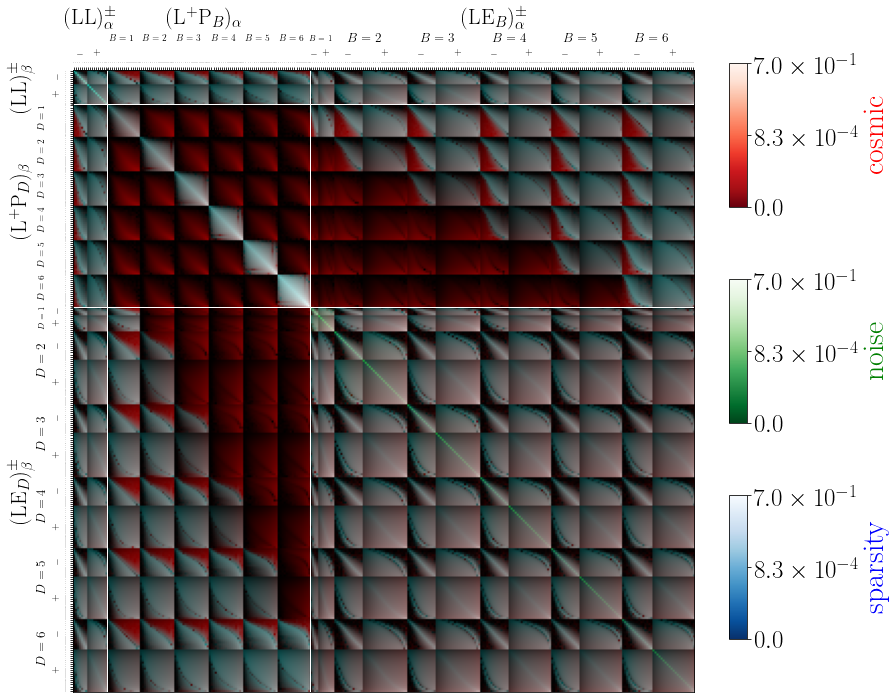

In [53]:
# Create the visualization
fig = plot_covariance(covariance_data, 
                              correlations_data, 
                              scale=True, 
                              normalize=True, 
                              log_scale=True, 
                              plot_colours = True,  #set to false to plot the total covariance
                              plot_noise = True,
                              plot_cosmic = True,
                              plot_sparsity = True,
                              eps = 1e-6, 
                              gamma = 1, 
                              eta = 1,
                              verbose=False)

fig.tight_layout(rect=[0, 0, 0.9, 1])

#eps, gamma and eta change the contrast of the plot
#warning, if you change eta, then the numbers on the colourbars are no longer strictly true

# Show the plot
fig.savefig(
    #f"Covariance_{nd['Nlens']}_sigL={nd['sigL']}.pdf",
    "covmat_test.png",
    bbox_inches='tight',
    dpi=600)

plt.show()

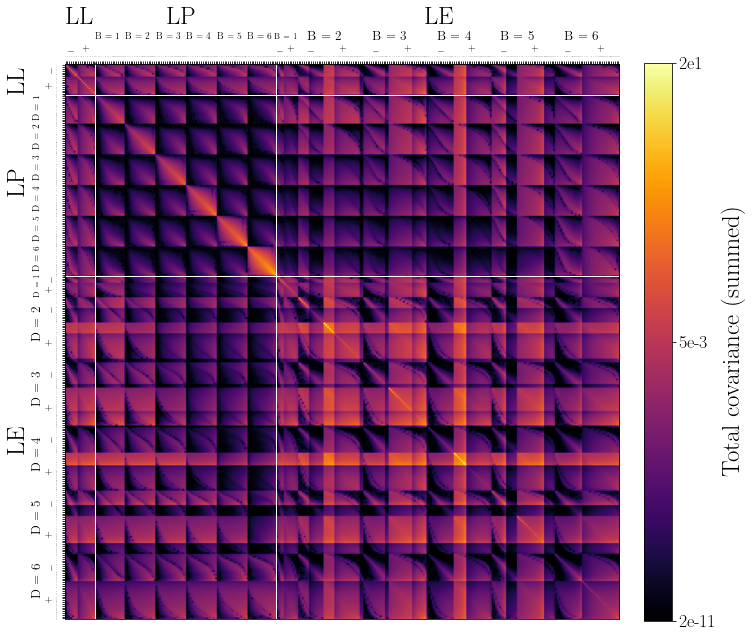

In [12]:
# Create the visualization
fig = plot_covariance(covariance_data, 
                              correlations_data, 
                              scale=True, 
                              normalize=True, 
                              log_scale=True, 
                              plot_colours = False,  #set to false to plot the total covariance
                              plot_noise = True,
                              plot_cosmic = True,
                              plot_sparsity = True,
                              eps = 1e-6, 
                              gamma = 1, 
                              eta = 1)

fig.tight_layout(rect=[0, 0, 0.9, 1])

#eps, gamma and eta change the contrast of the plot
#warning, if you change eta, then the numbers on the colourbars are no longer strictly true

# Show the plot
# fig.savefig("Covariance.png", bbox_inches='tight')
plt.show()

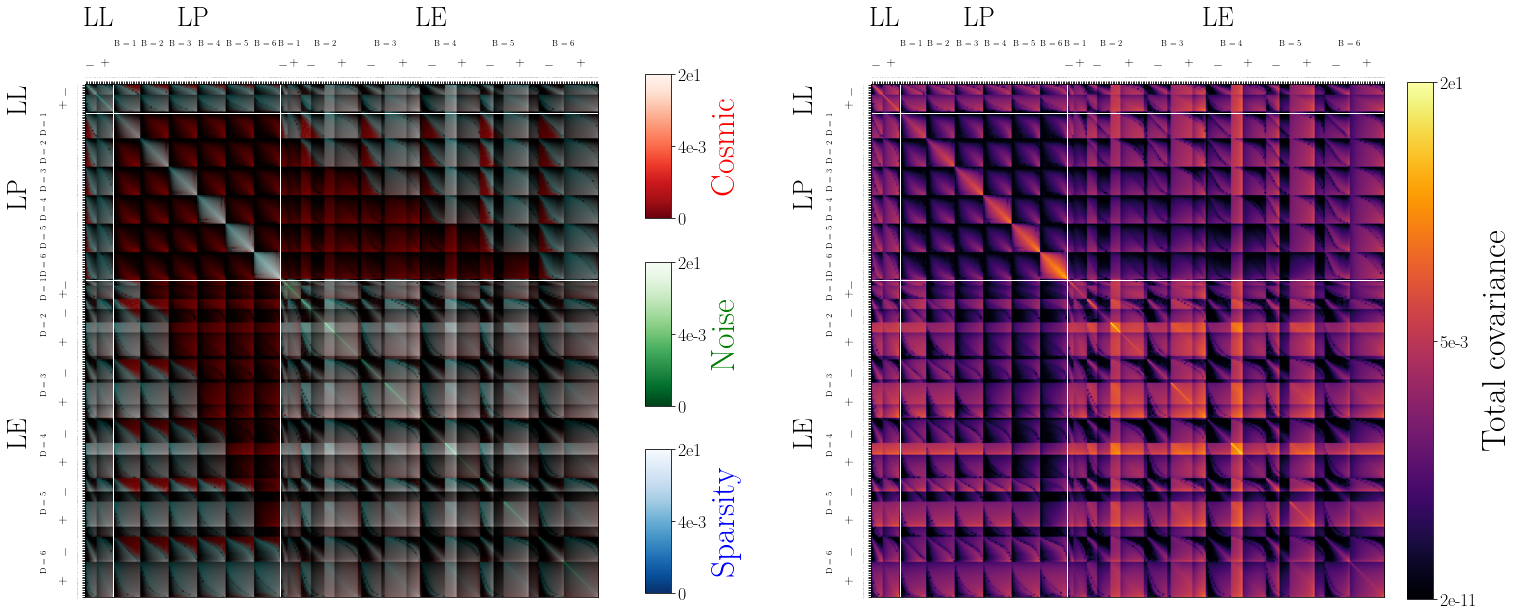

In [14]:
fig = plot_double_covariance(covariance_data, 
                              correlations_list, 
                              scale=True, 
                              variance_scale=False,
                              normalize=True, 
                              log_scale=True, 
                              plot_noise = True,
                              plot_cosmic = True,
                              plot_sparsity = True,
                              eps = 1e-6, 
                              gamma = 1, 
                              eta = 1,
                              titles=("Covariance", "Covariance uncertainty"))

## 5. Plotting sub-matrices<a id='plot_sub-matrices'></a>
[Back to contents](#contents) 

### A. Defining useful dictionaries<a id='useful_dictionaries'></a>
[Back to contents](#contents)

In [15]:
sizes = {'LL': angular_bin_dictionary['LL'][0],
 'LP': np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]),
 'LE': np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)])
    }

indices = {'LL': (0, sizes['LL']),
 'LP': (sizes['LL'], sizes['LL'] + sizes['LP']),
 'LE': (sizes['LL'] + sizes['LP'], sizes['LL'] + sizes['LP'] + sizes['LE'])
    }

correlation_names = {'LL': r'$\mathrm{LL}$',
 'LP': r'$\mathrm{LP}$',
 'LE': r'$\mathrm{LE}$'
    }

### B. Code to plot a covariance block<a id='code_covariance_block'></a>
[Back to contents](#contents)

In [16]:
def plot_covariance_block(covariance_data, correlations_data, corrs, 
                          scale=True, normalize=True, log_scale=True, figsize=(8, 6), plot_colours=True,
                          plot_noise=True, plot_cosmic=True, plot_sparsity=True, redshift_bins = None):
    """
    Plots a specific block of the covariance matrix, allowing selective inclusion of noise, cosmic, and sparsity components.
    """

    corr1 = corrs[0]
    corr2 = corrs[1]
    
    stop = False

    if redshift_bins is not None:
        b1_name = str(redshift_bins[0])
        b2_name = str(redshift_bins[1])
        for i, redshift_bin in enumerate(redshift_bins):
            if type(redshift_bin) != int or redshift_bin > Nbinz[corrs[i]]:
                print(f'Error: Invalid redshift binning - bins must be integers from 0 to {Nbinz[corrs[i]]-1}')
                stop = True
            elif corrs[i] == 'LL' and redshift_bin > 0:
                print(f'Error: No redshift binning for LOS shear, only valid index is 0')
                stop = True
    else:
        b1_name = 'b'
        b2_name = 'b'

    if not stop:

        noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
            
        if scale:
            noise_mat /= np.outer(correlations_list, correlations_list)
            cosmic_mat /= np.outer(correlations_list, correlations_list)
            sparsity_mat /= np.outer(correlations_list, correlations_list)
        
        noise_mat = extract_block(noise_mat, corr1, corr2)
        cosmic_mat = extract_block(cosmic_mat, corr1, corr2)
        sparsity_mat = extract_block(sparsity_mat, corr1, corr2)
    
        if redshift_bins is not None:
            noise_mat = extract_redshift_bin(noise_mat, corr1, corr2, redshifts = redshift_bins)
            cosmic_mat = extract_redshift_bin(cosmic_mat, corr1, corr2, redshifts = redshift_bins)
            sparsity_mat = extract_redshift_bin(sparsity_mat, corr1, corr2, redshifts = redshift_bins)

        if plot_colours:
            
            eps = 1e-6
            eps = max(eps, np.min(np.abs([noise_mat, cosmic_mat, sparsity_mat])))
            
            if log_scale:
                noise_mat = np.log1p((np.abs(noise_mat)) / eps)
                cosmic_mat = np.log1p((np.abs(cosmic_mat)) / eps)
                sparsity_mat = np.log1p((np.abs(sparsity_mat)) / eps)
    
            # Select matrices to plot based on user input
            components = []
            colors = []
            
            if plot_noise:
                components.append(noise_mat)
                colors.append(1)  # Green
            if plot_cosmic:
                components.append(cosmic_mat)
                colors.append(0)  # Red
            if plot_sparsity:
                components.append(sparsity_mat)
                colors.append(2)  # Blue
        
            # Normalize if enabled
            if normalize and components:
                max_val = max(np.max(mat) for mat in components)
                if max_val > 0:
                    components = [mat / max_val for mat in components]
        
            # Initialize RGB matrix
            rgb_matrix = np.zeros(noise_mat.shape + (3,))
            
            # Assign selected components to RGB channels
            for mat, color in zip(components, colors):
                rgb_matrix[..., color] = mat  
        
            # Plot the covariance block
            fig, ax = plt.subplots(figsize=figsize)
            ax.imshow(rgb_matrix, aspect='equal')

        else:

            total_mat = np.zeros_like(noise_mat)
            
            if plot_noise:
                total_mat += noise_mat
            if plot_cosmic:
                total_mat += cosmic_mat
            if plot_sparsity:
                total_mat += sparsity_mat
            
            eps = 1
            eps = max(eps, np.min(np.abs([total_mat])))
            
            if log_scale:
                total_mat = np.log((np.abs(total_mat)) / eps)
    
            # Normalize if enabled
            if normalize:
                max_val = np.max(total_mat)
                if max_val > 0:
                    total_mat = total_mat/max_val
                    
            vmin = np.min(total_mat)
            vmax = np.max(total_mat)
        
            # Plot the covariance block
            fig, ax = plt.subplots(figsize=figsize)
            im = ax.imshow(
                total_mat,
                aspect='equal',
                cmap='inferno',
                vmin=vmin,
                vmax=vmax,
            )
            
        ax.set_title(r'$[$'+corr1+ '(a; ' + b1_name + '), '+corr2+ '(a; ' + b2_name + r')$]$')
        plt.show()

### C. Plotting the block<a id='plot_block'></a>
[Back to contents](#contents)

Choose the pair of correlation functions you want the covariance matrix of in "correlation_pair"

Specify the redshift bins you're interested in in bbins
If you want all the redshift bins, set bbins = None

If you want to turn off a particular source of uncertainty, set it to False

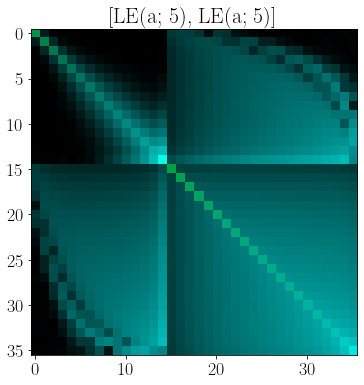

In [17]:
bbins = (5,5)
# bbins = None
correlation_pair = ('LE', 'LE')

plot_covariance_block(covariance_data, 
                      correlations_data, 
                      correlation_pair, 
                      plot_colours = True,  #set to false to plot the total covariance
                      plot_noise=True, 
                      plot_cosmic=False, 
                      plot_sparsity=True, 
                      scale = True,
                      log_scale=True, 
                      redshift_bins = bbins)


## 6. Signal vs noise<a id='signal_vs_noise'></a>
[Back to contents](#contents) 

### A. Plotting a single graph <a id='plot_single_graph'></a>
[Back to contents](#contents)

In [45]:
def plot_signal_vs_noise(corr, redshift, pm, showlegend=False, filename=''):

    if corr == 'LL':
        Thetas_rad = angular_distributions[f'{corr}_{pm}'].Thetas
    elif corr == 'LE':
        Thetas_rad = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
    else:
        Thetas_rad = angular_distributions[corr][redshift].Thetas
    
    #Thetas = Thetas_rad * 180/np.pi # get degrees
    Thetas = Thetas_rad * 180/np.pi * 60 # get arcmin

    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
    
    variance = []
    blocks = []
    
    for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
        
        all_redshifts = extract_block(matrix, corr, corr)
        
        block = extract_redshift_bin(all_redshifts, corr, corr, redshifts = (redshift, redshift))

        blocks.append(block)
        
        variance.append(compute_variance(block, corr, pm, redshift))
    
    total_covariance = blocks[0]+blocks[1]+blocks[2]
    
    total_variance = compute_variance(total_covariance, corr, pm, redshift)
    
    if corr == 'LL':
        correlations = np.abs(correlations_data[corr][pm + '_correlation'])
        if pm == 'plus':
            ylabel = r"$\mathrm{LL}^+$"
        elif pm == 'minus':
            ylabel = r"$\mathrm{LL}^-$"

        if redshift != 0:
            print("Warning! Redshift must equal 0 for LL")
    
    elif corr == 'LP':
        correlations = np.abs(correlations_data[corr][redshift]['correlation'])
        ylabel = r"$\mathrm{LP}$"
    
    elif corr == 'LE':
        correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])
        if pm == 'plus':
            ylabel = r"$\mathrm{LE}^+$"
        elif pm == 'minus':
            ylabel = r"$\mathrm{LE}^-$"

    fig, ax = plt.subplots(figsize=(5.5, 4))  
    
    ax.loglog(Thetas, correlations, 'o-', label="signal", color = 'black')
    
    ax.loglog(Thetas, total_variance, alpha=0.4, color='black', label="uncertainty")
    ax.fill_between(Thetas, total_variance, alpha=0.1, color='black')  # Corrected
    #print(Thetas*60)
    
    #ax.semilogy(Thetas, variance[1], '--', color='red', label="cosmic")
    #ax.semilogy(Thetas, variance[0], '-.', color='green', label="noise")
    #ax.semilogy(Thetas, variance[2], ':', color='blue', label="sparsity")
    
    ax.loglog(Thetas, variance[1], '--', color='red', label="cosmic")
    ax.loglog(Thetas, variance[0], '-.', color='green', label="noise")
    ax.loglog(Thetas, variance[2], ':', color='blue', label="sparsity")
    
    ax.set_ylabel(ylabel)
    # ax.set_ylim([3e-7, 2e-5])
    ax.set_xlim([1, 300])
    ax.set_xlabel(r"bin mean separation $\bar{\vartheta}_\alpha$ [arcmin]")
    
    if showlegend:
        ax.legend(fontsize='small', frameon=False)  # Add legend
    
    if filename != '':
        plt.savefig(path+filename, bbox_inches='tight')
        
    plt.show() 

Specify the correlation function, the redshift bin, and plus or minus (for LE and LL)

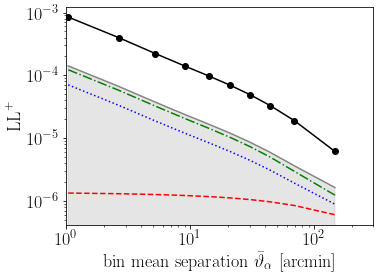

In [48]:
plot_signal_vs_noise('LL', 0, 'plus', showlegend=False, filename='LL+_signal_noise.pdf')

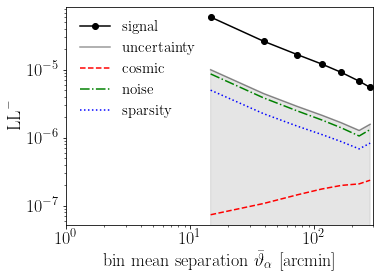

In [49]:
plot_signal_vs_noise('LL', 0, 'minus', showlegend=True, filename='LL-_signal_noise.pdf')

### B. Plotting a grid of graphs<a id='plot_grid_graph'></a>
[Back to contents](#contents)

In [22]:
#plt.rcParams.update({
#    "font.size": 26,          # default text size
#    "axes.titlesize": 24,     # title size
#    "axes.labelsize": 30,     # x and y labels
#    "xtick.labelsize": 20,    # x tick labels
#    "ytick.labelsize": 20,    # y tick labels
#    "legend.fontsize": 23,    # legend text
#})


def plot_signal_vs_noise2(covariance_data, corr):

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    
    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
    
    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']  # Two columns for LL and LE
    ncols = len(pm_values)  # Number of columns
    nrows = 1 if corr == 'LL' else Nbin_z  # Number of rows
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4), layout='constrained')
    
    # Pierre's note: there's an issue when I run this cell.
    # The loop on 'redshift' does not run, because -- I think -- the subplot array created
    # with nrows=1 is treated by Python as a one-dimensional array rather than a two-dimensional array;
    # hence it does not accept the 'redshift' index.
    # Weirdly enough, it was running at first, but at the second or third evaluation it stopped working...
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas_rad = angular_distributions[f'{corr}'][redshift].Thetas
            elif corr == 'LE':
                Thetas_rad = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas_rad = angular_distributions[f'{corr}_{pm}'].Thetas
                
            Thetas = Thetas_rad * 180/np.pi # get degrees
    
            ax = axes[redshift, j]
            
            variance = []
            blocks = []
            
            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))
            
            total_covariance = sum(blocks)
            total_variance = compute_variance(total_covariance, corr, pm, redshift)
            
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])
            
            ax.semilogy(Thetas, correlations, 'o-', label="signal", color='purple')
            ax.semilogy(Thetas, total_variance, color='black', label="total uncertainty")
            ax.fill_between(Thetas, total_variance, alpha=0.2, color='black')
            ax.semilogy(Thetas, variance[0], '-.', color='green', label="noise")
            ax.semilogy(Thetas, variance[1], '--', color='red', label="cosmic")
            ax.semilogy(Thetas, variance[2], ':', color='blue', label="sparsity")

            if corr == 'LL':
                if pm == 'plus':
                    ax.set_ylabel(correlation_names[corr]+'$^{+}$')
                elif pm == 'minus':
                    ax.set_ylabel(correlation_names[corr]+'$^{-}$')
            else:
                ax.set_ylabel(correlation_names[corr])
            ax.set_xlim([min(Thetas), max(Thetas)])
            ax.set_ylim([5e-8, 1e-3])
            ax.set_xlabel(r"bin median separation $\bar{\vartheta}_\alpha$ [deg]")
            if redshift == 0 and corr == 'LE':
                ax.set_title(f" {pm}, b = {redshift}")
            elif corr == 'LP':
                ax.set_title(f" b = {redshift}")
            if j ==0:
                ax.legend(loc='upper right')
    
    # plt.savefig('LL_sources_of_uncertainty.pdf')
    plt.show()

def plot_signal_vs_noise2(covariance_data, corr):

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    
    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
    
    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']  # Two columns for LL and LE
    ncols = len(pm_values)  # Number of columns
    nrows = 1 if corr == 'LL' else Nbin_z  # Number of rows
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5), squeeze=False, layout='constrained')
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas_rad = angular_distributions[f'{corr}'][redshift].Thetas
            elif corr == 'LE':
                Thetas_rad = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas_rad = angular_distributions[f'{corr}_{pm}'].Thetas
                
            Thetas = Thetas_rad * 180/np.pi # get degrees
    
            ax = axes[redshift, j]
            
            variance = []
            blocks = []
            
            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))
            
            total_covariance = sum(blocks)
            total_variance = compute_variance(total_covariance, corr, pm, redshift)
            
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])
            
            ax.semilogy(Thetas, correlations, 'o-', label="signal", color='purple')
            ax.semilogy(Thetas, total_variance, color='black', label="total uncertainty")
            ax.fill_between(Thetas, total_variance, alpha=0.2, color='black')
            ax.semilogy(Thetas, variance[0], '-.', color='green', label="noise")
            ax.semilogy(Thetas, variance[1], '--', color='red', label="cosmic")
            ax.semilogy(Thetas, variance[2], ':', color='blue', label="sparsity")

            if corr == 'LL':
                if pm == 'plus':
                    ax.set_ylabel(correlation_names[corr]+'$^{+}$')
                elif pm == 'minus':
                    ax.set_ylabel(correlation_names[corr]+'$^{-}$')
            else:
                ax.set_ylabel(correlation_names[corr])
            ax.set_xlim([min(Thetas), max(Thetas)])
            ax.set_ylim([5e-8, 1e-3])
            ax.set_xlabel(r"bin median separation $\bar{\vartheta}_\alpha$ [deg]")
            if redshift == 0 and corr == 'LE':
                ax.set_title(f" {pm}, b = {redshift}")
            elif corr == 'LP':
                ax.set_title(f" b = {redshift}")
            if j ==0:
                ax.legend(loc='upper right')
    
    # plt.savefig('LL_sources_of_uncertainty.pdf')
    plt.show()


Specify only the correlation function you're interested in

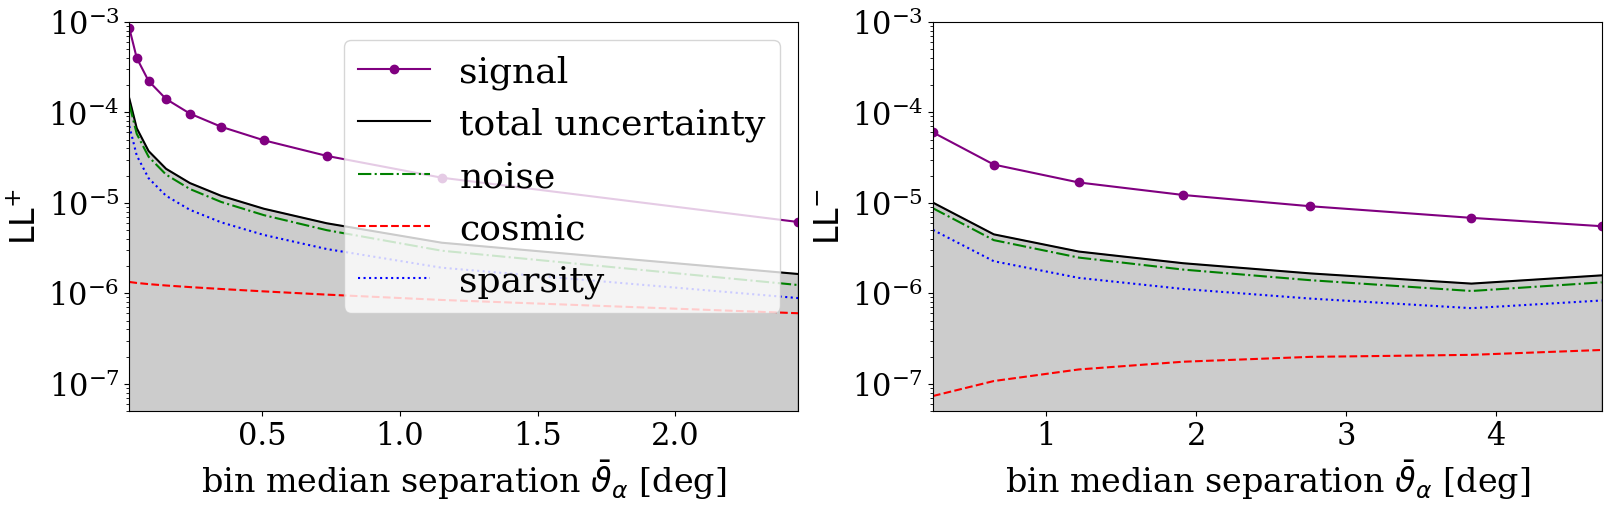

In [320]:
plot_signal_vs_noise2(covariance_data, 'LL')

LL signal and noise for the paper

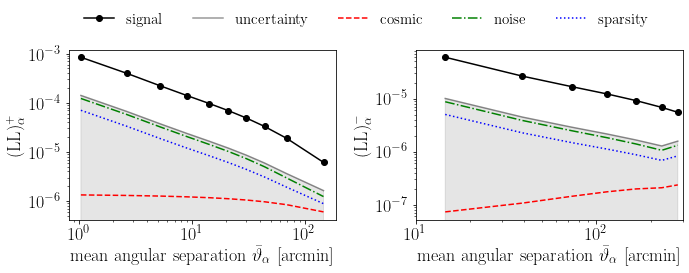

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=False)
corr = 'LL'

for i, pm in enumerate(['plus', 'minus']):
    
    Thetas_rad = angular_distributions[f'{corr}_{pm}'].Thetas
    Thetas = Thetas_rad * 180/np.pi * 60 # get arcmin
    redshift = 0
    
    # Get signal
    signal = np.abs(correlations_data['LL'][pm + '_correlation'])
    
    # Get variance
    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
    
    variance = []
    blocks = []
    
    for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
        
        all_redshifts = extract_block(matrix, corr, corr)
        block = extract_redshift_bin(all_redshifts, corr, corr, redshifts = (redshift, redshift))
        blocks.append(block)
        variance.append(compute_variance(block, corr, pm, redshift))
        
    total_covariance = blocks[0]+blocks[1]+blocks[2]
    total_variance = compute_variance(total_covariance, corr, pm, redshift)
    
    ax = axes[i]
    
    signal_hdl, = ax.loglog(Thetas, signal, 'o-', label="signal", color = 'black')
    
    uncertainty_hdl,  = ax.loglog(Thetas, total_variance, alpha=0.4, color='black', label="uncertainty")
    ax.fill_between(Thetas, total_variance, alpha=0.1, color='black')  # Corrected
    
    cosmic_hdl,   = ax.loglog(Thetas, variance[1], '--', color='red', label="cosmic")
    noise_hdl,    = ax.loglog(Thetas, variance[0], '-.', color='green', label="noise")
    sparsity_hdl, = ax.loglog(Thetas, variance[2], ':', color='blue', label="sparsity")
    
    if pm == 'plus':
        ylabel = r"$(\mathrm{LL})^+_\alpha$"
    elif pm == 'minus':
        ylabel = r"$(\mathrm{LL})^-_\alpha$"
    ax.set_ylabel(ylabel)
    # ax.set_ylim([3e-7, 2e-5])
    #ax.set_xlim([1, 300])
    ax.set_xlabel(r"mean angular separation $\bar{\vartheta}_\alpha$ [arcmin]")
    
ax.set_xlim([10, 300])    
    
handles = [signal_hdl, uncertainty_hdl, cosmic_hdl, noise_hdl, sparsity_hdl]
labels = [h.get_label() for h in handles]

fig.legend(handles, labels,
           fontsize='small',
           loc='upper center',
           bbox_to_anchor=(0.5, 1),
           ncol=5,
           frameon=False)

plt.subplots_adjust(top=0.8, wspace=0.3)

plt.savefig(path+'optimistic_LL_noise_breakdown.pdf', bbox_inches='tight')
plt.show() 

In [ ]:
def plot_signal_vs_noise(corr, redshift, pm, showlegend=False, filename=''):

    if corr == 'LL':
        Thetas_rad = angular_distributions[f'{corr}_{pm}'].Thetas
    elif corr == 'LE':
        Thetas_rad = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
    else:
        Thetas_rad = angular_distributions[corr][redshift].Thetas
    
    #Thetas = Thetas_rad * 180/np.pi # get degrees
    Thetas = Thetas_rad * 180/np.pi * 60 # get arcmin

    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
    
    variance = []
    blocks = []
    
    for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
        
        all_redshifts = extract_block(matrix, corr, corr)
        
        block = extract_redshift_bin(all_redshifts, corr, corr, redshifts = (redshift, redshift))

        blocks.append(block)
        
        variance.append(compute_variance(block, corr, pm, redshift))
    
    total_covariance = blocks[0]+blocks[1]+blocks[2]
    
    total_variance = compute_variance(total_covariance, corr, pm, redshift)
    
    if corr == 'LL':
        correlations = np.abs(correlations_data[corr][pm + '_correlation'])
        if pm == 'plus':
            ylabel = r"$\mathrm{LL}^+$"
        elif pm == 'minus':
            ylabel = r"$\mathrm{LL}^-$"

        if redshift != 0:
            print("Warning! Redshift must equal 0 for LL")
    
    elif corr == 'LP':
        correlations = np.abs(correlations_data[corr][redshift]['correlation'])
        ylabel = r"$\mathrm{LP}$"
    
    elif corr == 'LE':
        correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])
        if pm == 'plus':
            ylabel = r"$\mathrm{LE}^+$"
        elif pm == 'minus':
            ylabel = r"$\mathrm{LE}^-$"

    fig, ax = plt.subplots(figsize=(5.5, 4))  
    
    ax.loglog(Thetas, correlations, 'o-', label="signal", color = 'black')
    
    ax.loglog(Thetas, total_variance, alpha=0.4, color='black', label="uncertainty")
    ax.fill_between(Thetas, total_variance, alpha=0.1, color='black')  # Corrected
    #print(Thetas*60)
    
    #ax.semilogy(Thetas, variance[1], '--', color='red', label="cosmic")
    #ax.semilogy(Thetas, variance[0], '-.', color='green', label="noise")
    #ax.semilogy(Thetas, variance[2], ':', color='blue', label="sparsity")
    
    ax.loglog(Thetas, variance[1], '--', color='red', label="cosmic")
    ax.loglog(Thetas, variance[0], '-.', color='green', label="noise")
    ax.loglog(Thetas, variance[2], ':', color='blue', label="sparsity")
    
    ax.set_ylabel(ylabel)
    # ax.set_ylim([3e-7, 2e-5])
    ax.set_xlim([1, 300])
    ax.set_xlabel(r"bin mean separation $\bar{\vartheta}_\alpha$ [arcmin]")
    
    if showlegend:
        ax.legend(fontsize='small', frameon=False)  # Add legend
    
    if filename != '':
        plt.savefig(path+filename, bbox_inches='tight')
        
    plt.show() 

### C. Linear plot with error bars<a id='linear_plot_error_bars'></a>
[Back to contents](#contents)

In [321]:
def plot_signal_vs_noise3(covariance_data, corr):
    
    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
    
    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']  # Two columns for LL and LE
    ncols = len(pm_values)  # Number of columns
    nrows = 1  # Number of rows
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, 6 * nrows), squeeze=False)

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas_rad = angular_distributions[f'{corr}'][redshift].Thetas
            elif corr == 'LE':
                Thetas_rad = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas_rad = angular_distributions[f'{corr}_{pm}'].Thetas
                
            Thetas = Thetas_rad * 180/np.pi # get degrees
                
            
            ax = axes[0, j]
            
            variance = []
            blocks = []
            
            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))
            
            total_covariance = sum(blocks)
            total_variance = compute_variance(total_covariance, corr, pm, redshift)
            
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])
            
            ax.errorbar(
                    Thetas,
                    correlations,
                    yerr=total_variance,
                    fmt='o-',
                    label=f"b={redshift}",
                    ecolor='black',
                    capsize=3
                )
            
            ax.set_ylabel(correlation_names[corr])
            # ax.set_xlim([min(Thetas), max(Thetas)])
            ax.set_xlabel(r"bin median separation $\bar{\vartheta}_\alpha$ [deg]")
            if redshift == 0 and corr != 'LP':
                ax.set_title(f" {pm}")
            ax.legend(loc='upper right')
    
    plt.tight_layout()
    # plt.savefig('Signal_vs_Noise_array.pdf')
    plt.show()

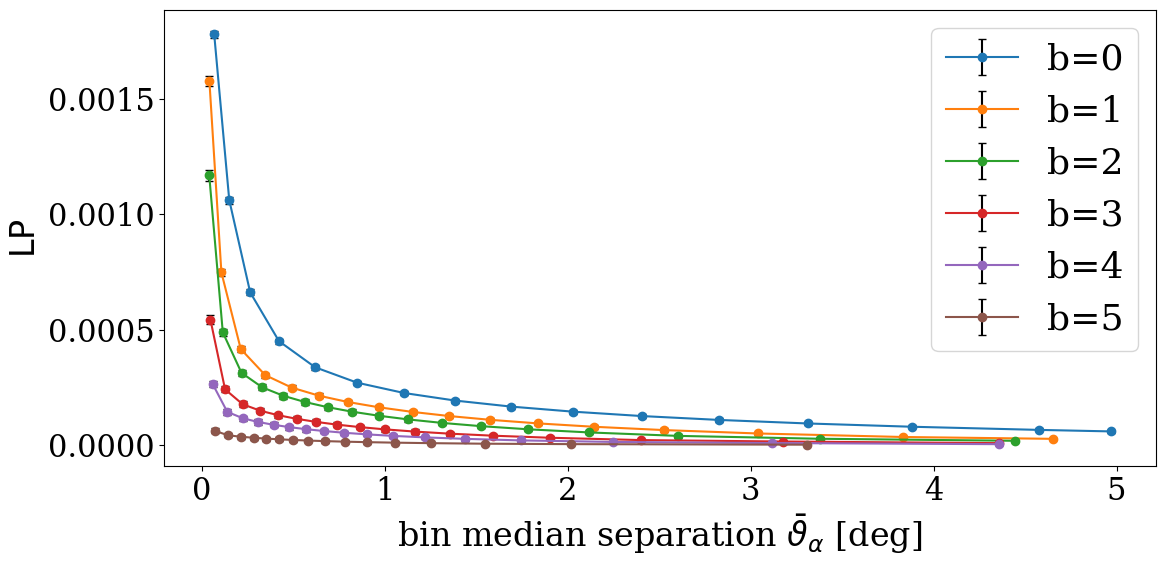

In [322]:
plot_signal_vs_noise3(covariance_data, 'LP')

### D. Log-linear plot with ax.fill_between<a id='semilog_w_fill'></a>
[Back to contents](#contents)

In [323]:
#import matplotlib.colors as mcolors

#plt.rcParams.update({
#    "font.size": 26,          # default text size
#    "axes.titlesize": 24,     # title size
#    "axes.labelsize": 32,     # x and y labels
#    "xtick.labelsize": 28,    # x tick labels
#    "ytick.labelsize": 28,    # y tick labels
#    "legend.fontsize": 28,    # legend text
#})


def plot_signal_vs_noise4(covariance_data, corr):

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    cmap = plt.get_cmap('tab10', Nbin_z)

    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)

    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']
    ncols = len(pm_values)
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 6 * nrows), squeeze=False, layout='constrained')
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas = angular_distributions[corr][redshift].Thetas
            elif corr == 'LE':
                Thetas = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas = angular_distributions[f'{corr}_{pm}'].Thetas
                     
            ax = axes[0, j]

            variance = []
            blocks = []

            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))

            total_covariance = sum(blocks)
            sigma = compute_variance(total_covariance, corr, pm, redshift)

            # === Get correlations ===
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])

            # === Clip small values to avoid log issues ===
            correlations = np.clip(correlations, 1e-12, None)
            sigma = np.clip(sigma, 1e-12, None)
            lower = np.clip(correlations - sigma, 1e-12, None)
            upper = correlations + sigma

            # === Transform into log10 space ===
            log_corr = np.log10(correlations)
            log_lower = np.log10(lower)
            log_upper = np.log10(upper)
            
            # === Plot ===
            color = cmap(redshift)  # Get unique color per redshift bin

            if redshift == 5 and corr == 'LP':      
                Thetas = Thetas[:-2]
                log_corr = log_corr[:-2]
                log_lower = log_lower[:-2]
                log_upper = log_upper[:-2]
            

            if redshift == 4 and corr == 'LP':      
                Thetas = Thetas[:-1]
                log_corr = log_corr[:-1]
                log_lower = log_lower[:-1]
                log_upper = log_upper[:-1]
                
            ax.plot(Thetas * 180/np.pi, log_corr, 'o-', color=color, label=f"{1+redshift}")
            ax.fill_between(Thetas * 180/np.pi, log_lower, log_upper, color=color, alpha=0.3)

            if corr == 'LP':
                ax.set_ylabel(fr"log$_{{10}}$ {correlation_names[corr]}")
            elif j == 0:
                ax.set_ylabel(fr"log$_{{10}}$ {correlation_names[corr]}$^+$")
                # ax.set_ylim(ymin=-6.5)
            elif j == 1:
                ax.set_ylabel(fr"log$_{{10}}$ {correlation_names[corr]}$^-$")
            # ax.set_xlim([min(Thetas), max(Thetas)])
            ax.set_xlabel(r"bin median separation $\bar{\vartheta}_\alpha$ [deg]")

            # if redshift == 0 and corr != 'LP':
                # ax.set_title(f" {pm}")
            if corr != 'LL' and Nbin_z > 1 and pm != 'minus':
                ax.legend(title = r'$z$ bin')

    # plt.ylim(-6,-2.6)
    # plt.savefig(f'Correlations_{corr}_Nlens={nd['Nlens']}_sigL={nd['sigL']}.pdf')
    plt.show()

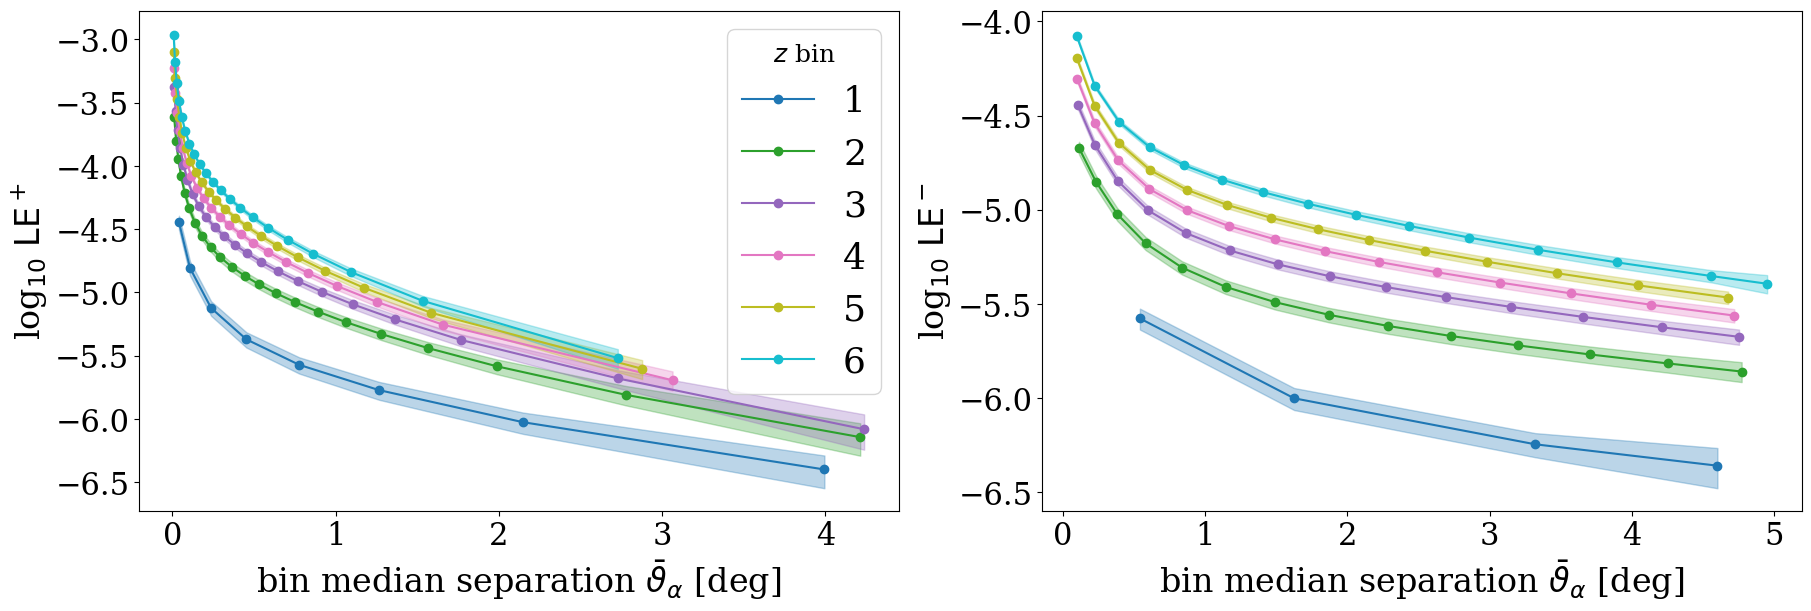

In [324]:
plot_signal_vs_noise4(covariance_data, 'LE')

### E. Signal-to-noise ratio<a id='SNR'></a>
[Back to contents](#contents)

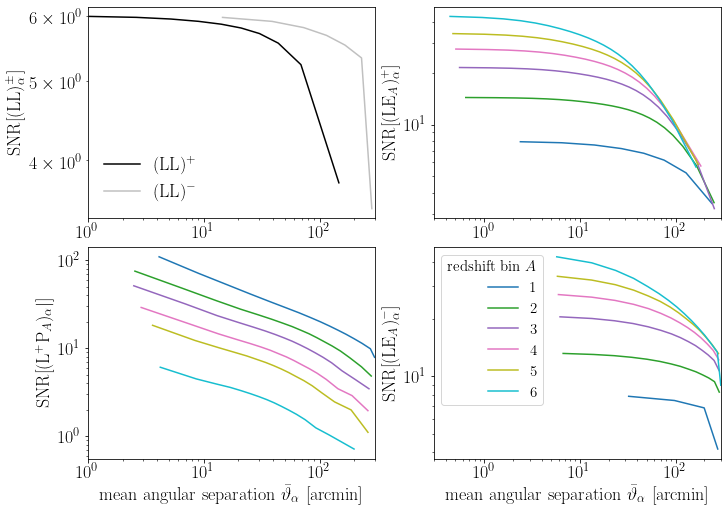

In [52]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 7),
                         sharex=False, sharey=False, constrained_layout=True)

# Structure of the plot
#
# LL LE+
# LP LE-

# Top-left panel: LL+ and LL-

ax = axes[0, 0]
corr = 'LL'
pms = ['plus', 'minus']
redshift = 0
colors = ['black', 'silver']
labels = [r'$({\rm LL})^+$', r'$({\rm LL})^-$']

for i, pm in enumerate(pms):

    # get angles
    Thetas = angular_distributions[f'{corr}_{pm}'].Thetas

    # get signal
    signal = np.abs(correlations_data[corr][pm + '_correlation'])

    # get uncertainty
    submatrix = extract_block(covmat, corr, corr)
    block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
    sigma = compute_variance(block, corr, pm, redshift)
    
    SNR = signal/sigma

    # plot
    color = colors[i]
    Thetas_arcmin = Thetas * 180/np.pi * 60
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.plot(Thetas_arcmin, SNR,
            '-', color=color, label=labels[i])
    ax.set_xlim([1,300])

    # labels and legends
    ax.set_ylabel(r'$\mathrm{SNR}[({\rm L}{\rm L})^\pm_\alpha]$')
    ax.legend(frameon=False)

# Bottom-left panel: LP

ax = axes[1, 0]
corr = 'LP'
Nbin_z = Nbinz[corr]
cmap = plt.get_cmap('tab10', Nbin_z)

for redshift in range(Nbin_z):

    # get angles
    Thetas = angular_distributions[corr][redshift].Thetas

    # get signal
    signal = np.abs(correlations_data[corr][redshift]['correlation'])

    # get uncertainty
    submatrix = extract_block(covmat, corr, corr)
    block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
    sigma = compute_variance(block, corr, pm, redshift)

    SNR = signal/sigma

    # plot
    color = cmap(redshift)
    Thetas_arcmin = Thetas * 180/np.pi * 60
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.plot(Thetas_arcmin, SNR,
            '-', color=color, label=f"{1+redshift}")
    ax.set_xlim([1, 300])
    #ax.set_ylim(ymin=3e-7)

    # labels and legends
    ax.set_xlabel(r'mean angular separation $\bar{\vartheta}_\alpha$ [arcmin]')
    ax.set_ylabel(r'$\mathrm{SNR}[({\rm L}^+ {\rm P}_A)_\alpha|]$')

# right panels: LE

corr = 'LE'
Nbin_z = Nbinz[corr]
cmap = plt.get_cmap('tab10', Nbin_z)
pms = ['plus', 'minus']
ylabels = [r'$\mathrm{SNR}[({\rm L}{\rm E}_A)^+_\alpha]$',
            r'$\mathrm{SNR}[({\rm L}{\rm E}_A)^-_\alpha$]']

for i, pm in enumerate(pms):

    ax = axes[i, 1]

    for redshift in range(Nbin_z):

        # get angles
        Thetas = angular_distributions[f'{corr}_{pm}'][redshift].Thetas

        # get signal
        signal = np.abs(correlations_data[corr][redshift][pm + '_correlation'])

        # get uncertainty
        submatrix = extract_block(covmat, corr, corr)
        block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
        sigma = compute_variance(block, corr, pm, redshift)

        SNR = signal/sigma

        # plot
        color = colors[i]
        Thetas_arcmin = Thetas * 180/np.pi * 60
        ax.set_xscale('log')
        ax.set_yscale('log')

        color = cmap(redshift)
        ax.plot(Thetas_arcmin, SNR,
                '-', color=color, label=f"{1+redshift}")
        ax.set_xlim([0.3, 300])
        #ax.set_ylim(ymin=3e-7)

    # labels and legends
    ax.set_ylabel(ylabels[i])
    if i==1:
        ax.legend(
                title=r'redshift bin $A$',
                alignment='right',
                fontsize='small',
                title_fontsize='small',
                frameon=True)
        ax.set_xlabel(r'mean angular separation $\bar{\vartheta}_\alpha$ [arcmin]')
        

plt.savefig(path+'optimistic_all_SNR.pdf', bbox_inches='tight')
plt.show()


In [328]:
import matplotlib.colors as mcolors

plt.rcParams.update({
    "font.size": 26,          # default text size
    "axes.titlesize": 24,     # title size
    "axes.labelsize": 32,     # x and y labels
    "xtick.labelsize": 28,    # x tick labels
    "ytick.labelsize": 28,    # y tick labels
    "legend.fontsize": 28,    # legend text
})


def plot_signal_vs_noise4(covariance_data, corr):

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    cmap = plt.get_cmap('tab10', Nbin_z)

    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)

    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']
    ncols = len(pm_values)
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 6 * nrows), squeeze=False, layout='constrained')
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas = angular_distributions[corr][redshift].Thetas
            elif corr == 'LE':
                Thetas = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas = angular_distributions[f'{corr}_{pm}'].Thetas
                     
            ax = axes[0, j]

            variance = []
            blocks = []

            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))

            total_covariance = sum(blocks)
            sigma = compute_variance(total_covariance, corr, pm, redshift)

            # === Get correlations ===
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])

            # === Clip small values to avoid log issues ===
            correlations = np.clip(correlations, 1e-12, None)
            sigma = np.clip(sigma, 1e-12, None)
            lower = np.clip(correlations - sigma, 1e-12, None)
            upper = correlations + sigma

            # === Transform into log10 space ===
            log_corr = np.log10(correlations)
            log_lower = np.log10(lower)
            log_upper = np.log10(upper)
            
            # === Plot ===
            color = cmap(redshift)  # Get unique color per redshift bin

            if redshift == 5 and corr == 'LP':      
                Thetas = Thetas[:-2]
                log_corr = log_corr[:-2]
                log_lower = log_lower[:-2]
                log_upper = log_upper[:-2]
            

            if redshift == 4 and corr == 'LP':      
                Thetas = Thetas[:-1]
                log_corr = log_corr[:-1]
                log_lower = log_lower[:-1]
                log_upper = log_upper[:-1]
                
            ax.plot(Thetas * 180/np.pi, log_corr, 'o-', color=color, label=f"{1+redshift}")
            ax.fill_between(Thetas * 180/np.pi, log_lower, log_upper, color=color, alpha=0.3)

            if corr == 'LP':
                ax.set_ylabel(fr"log$_{{10}}$ {correlation_names[corr]}")
            elif j == 0:
                ax.set_ylabel(fr"log$_{{10}}$ {correlation_names[corr]}$^+$")
                # ax.set_ylim(ymin=-6.5)
            elif j == 1:
                ax.set_ylabel(fr"log$_{{10}}$ {correlation_names[corr]}$^-$")
            # ax.set_xlim([min(Thetas), max(Thetas)])
            ax.set_xlabel(r"bin median separation $\bar{\vartheta}_\alpha$ [deg]")

            # if redshift == 0 and corr != 'LP':
                # ax.set_title(f" {pm}")
            if corr != 'LL' and Nbin_z > 1 and pm != 'minus':
                ax.legend(title = r'$z$ bin')

    # plt.ylim(-6,-2.6)
    # plt.savefig(f'Correlations_{corr}_Nlens={nd['Nlens']}_sigL={nd['sigL']}.pdf')
    plt.show()

### F. Log-linear plot with error bars<a id='semilog_w_errorbars'></a>
[Back to contents](#contents)

In [329]:
def plot_signal_vs_noise5(covariance_data, corr):

    # Choose a colormap (e.g., tab10, viridis, etc.)
    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    cmap = plt.get_cmap('tab10', Nbin_z)  # or try 'viridis', 'plasma', etc.

    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)

    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']
    ncols = len(pm_values)
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 6 * nrows), squeeze=False)

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas = angular_distributions[corr][redshift].Thetas
            elif corr == 'LE':
                Thetas = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas = angular_distributions[f'{corr}_{pm}'].Thetas
                
            ax = axes[0, j]

            variance = []
            blocks = []

            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))

            total_covariance = sum(blocks)
            sigma = compute_variance(total_covariance, corr, pm, redshift)

            # === Get correlations ===
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])

            # === Clip small values to avoid log issues ===
            correlations = np.clip(correlations, 1e-12, None)
            sigma = np.clip(sigma, 1e-12, None)
            lower = np.clip(correlations - sigma, 1e-12, None)
            upper = correlations + sigma

            # convert to logspace
            log_corr = np.log10(correlations)
            log_err_low = log_corr - np.log10(np.clip(correlations - sigma, 1e-12, None)) #correlations - sigma gives 
            log_err_high = np.log10(correlations + sigma) - log_corr
            log_yerr = np.vstack((log_err_low, log_err_high))

            # plot 
            color = cmap(redshift)  # Get unique color per redshift bin
            
            ax.errorbar(
                Thetas,
                log_corr,
                yerr=log_yerr,
                fmt='o-',
                color=color,
                ecolor=color,
                capsize=3,
                label=f"{redshift}"
            )

            ax.set_ylabel(f"log$_{{10}}$ {correlation_names[corr]}")
            ax.set_xlabel(r"bin median separation $\bar{\vartheta}_\alpha$ [deg]")

            if redshift == 0 and corr != 'LP':
                ax.set_title(f" {pm}")
            if j != 1:
                ax.legend(title=f'$z$ bin')

    plt.tight_layout()
    # plt.savefig(f'Correlations2_{corr}.png')
    plt.show()

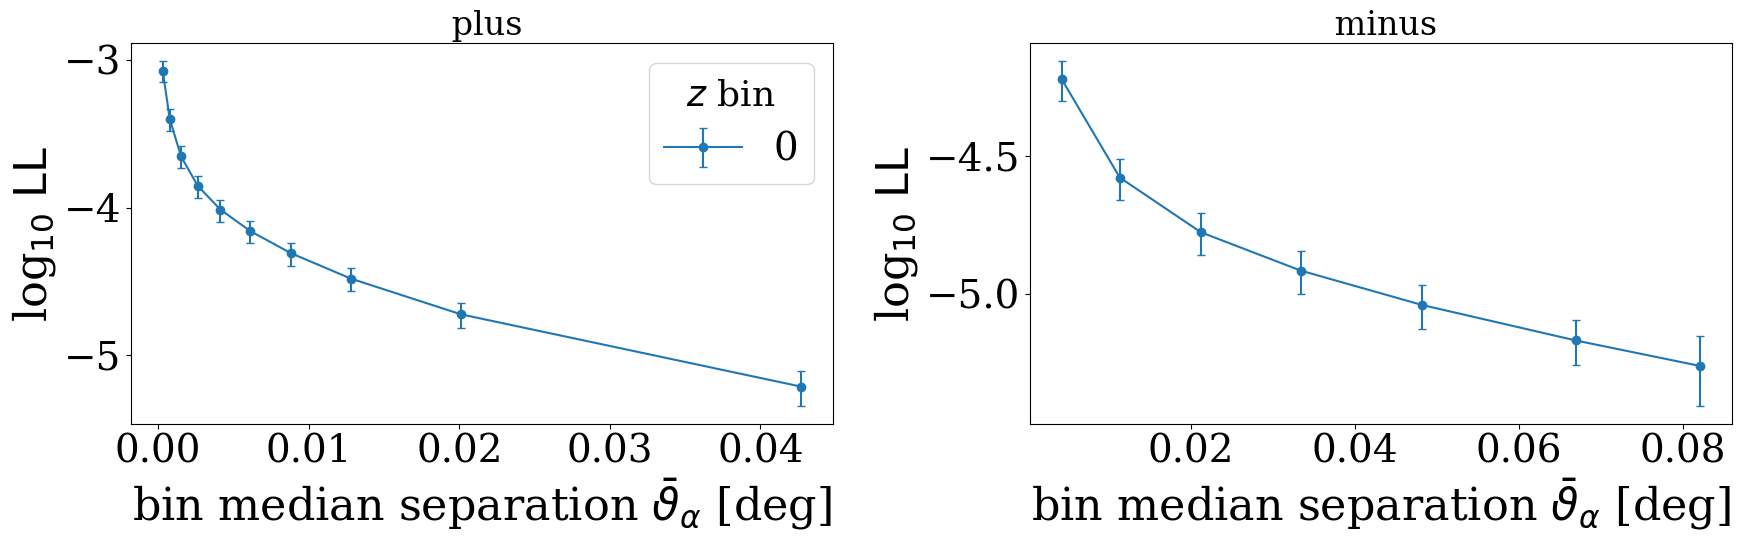

In [330]:
plot_signal_vs_noise5(covariance_data, 'LL')

### G. Log-linear plot with ax.fill_between (plus/minus on same graph)<a id='semilog_w_fill_pm'></a>
[Back to contents](#contents)

In [331]:
plot_colors = ['#002147', '#D64933', '#228B22']

plt.rcParams.update({
    "font.size": 22,          # default text size
    "axes.titlesize": 22,     # title size
    "axes.labelsize": 24,     # x and y labels
    "xtick.labelsize": 22,    # x tick labels
    "ytick.labelsize": 22,    # y tick labels
    "legend.fontsize": 26,    # legend text
})

def plot_signal_vs_noise6(covariance_data, corr):

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    cmap = plt.get_cmap('tab10', Nbin_z)

    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)

    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']
    ncols = 1
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 6 * nrows), squeeze=False)
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas = angular_distributions[corr][redshift].Thetas
            elif corr == 'LE':
                Thetas = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas = angular_distributions[f'{corr}_{pm}'].Thetas
                     
            ax = axes[0,0]

            variance = []
            blocks = []

            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))

            total_covariance = sum(blocks)
            sigma = compute_variance(total_covariance, corr, pm, redshift)

            # === Get correlations ===
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])

            # === Clip small values to avoid log issues ===
            correlations = np.clip(correlations, 1e-12, None)
            sigma = np.clip(sigma, 1e-12, None)
            lower = np.clip(correlations - sigma, 1e-12, None)
            upper = correlations + sigma

            # === Transform into log10 space ===
            log_corr = np.log10(correlations)
            log_lower = np.log10(lower)
            log_upper = np.log10(upper)
            
            # === Plot ===
            color = cmap(redshift)  # Get unique color per redshift bin

            if pm == 'plus':      
                Thetas = Thetas[:-1]
                log_corr = log_corr[:-1]
                log_lower = log_lower[:-1]
                log_upper = log_upper[:-1]

            if corr == 'LP':
                j = 2
            ax.plot(Thetas * 180/np.pi, log_corr, 'o-', color=plot_colors[j], label=f"{pm}")
            ax.fill_between(Thetas * 180/np.pi, log_lower, log_upper, color=plot_colors[j], alpha=0.3)

            ax.set_ylabel(fr"log$_{{10}}$ {correlation_names[corr]}")
            # ax.set_xlim([min(Thetas), max(Thetas)])
            ax.set_xlabel(r"bin median separation $\bar{\vartheta}_\alpha$ [deg]")

            if corr != 'LP':
                ax.legend()

    # plt.ylim(-6,-2.6)
    plt.tight_layout()
    # plt.savefig(f'Correlations_{corr}_Nlens={nd['Nlens']}_sigL={nd['sigL']}.pdf')
    plt.show()

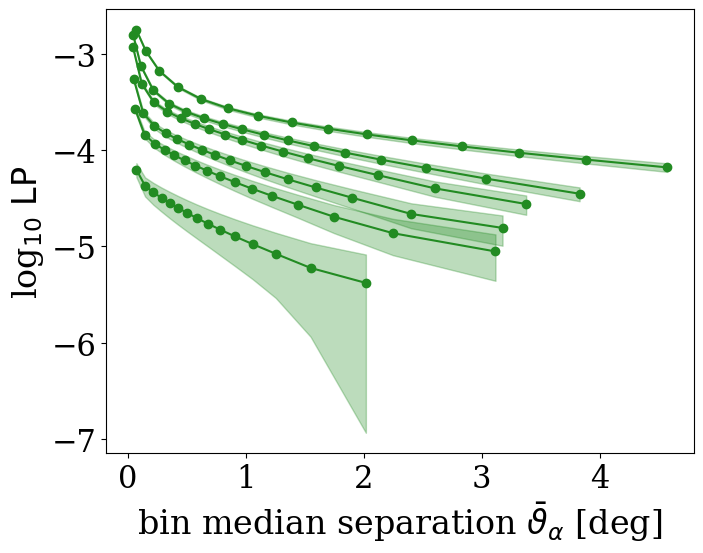

In [332]:
plot_signal_vs_noise6(covariance_data, 'LP')

## 7. Figures for the theory paper<a id='figures_theory_paper'></a>
[Back to contents](#contents)

### A. Optimistic scenario<a id='optimistic'></a>
[Back to contents](#contents)

Define dataset

In [54]:
supply_binscheme = False

nd = {'Nlens': '1e5',    
      'sigL': '0.05',
      'Nbin_z': '6',
      'Nbina': '6',           #only used if supply_binscheme == True
      'SNR_goal': '8',       #only used if supply_binscheme == False
      'Nbin_max': '20',       #only used if supply_binscheme == False
      'nsamp': '1e6',
      'notes': ''
}

folder_name = "Nlens={}_sigL={}_Nbin_z={}_SNR_goal={}_Nbin_max={}_nsamp={}{}".format(
    nd['Nlens'], nd['sigL'], nd['Nbin_z'], nd['SNR_goal'], nd['Nbin_max'], nd['nsamp'], nd['notes'])

Read in distributions

In [55]:
#the file containing the redshift distributions
redshift_distributions = load_file(f"data/{folder_name}/redshift_distributions")

Nbinz_E = redshift_distributions["E"].Nbinz
Nbinz_P = redshift_distributions["P"].Nbinz

Nbinz = {'LP': Nbinz_P,
         'LE': Nbinz_E,
         'LL': 0
        }

#the file containing the angular distributions
angular_distributions = load_file(f"data/{folder_name}/angular_distributions")

#LL

Nbina_LL_plus = angular_distributions["LL_plus"].Nbina
Nbina_LL_minus = angular_distributions["LL_minus"].Nbina

Nbina_LL = [angular_distributions["LL_plus"].Nbina + angular_distributions["LL_minus"].Nbina]

#LE

Nbina_LE_plus = []
Nbina_LE_minus = []
Nbina_LE = []

for b in range(Nbinz_E):
    
    Nbina_LE_plus.append(angular_distributions["LE_plus"][b].Nbina)
    Nbina_LE_minus.append(angular_distributions["LE_minus"][b].Nbina)

    Nbina_LE.append(angular_distributions["LE_plus"][b].Nbina + angular_distributions["LE_minus"][b].Nbina)

#LP

Nbina_LP = []

for b in range(Nbinz_P):
    
    Nbina_LP.append(angular_distributions["LP"][b].Nbina)

#dictionaries to store the data

angular_bin_dictionary = {'LL': Nbina_LL,
                          'LE': Nbina_LE,
                          'LP': Nbina_LP
                        }

angular_bin_dictionary_pm = {'LL': {'plus': [Nbina_LL_plus], 'minus': [Nbina_LL_minus]},
                          'LE': {'plus': Nbina_LE_plus, 'minus': Nbina_LE_minus},
                          'LP': Nbina_LP
                        }

Read in correlations

In [56]:
correlations_data = read_correlations(folder_name)

Read in covariance

In [57]:
folder_structure = {
    "LLLL": 0,  # No redshift binning
    "LLLE": 1,  # 1 redshift bin index
    "LELE": 2,  # 2 redshift bin indices
    "LLLP": 1,  # 1 redshift bin index
    "LPLP": 2,  # 2 redshift bin indices
    "LELP": 2,  # 2 redshift bin indices
}

Nbinz_map = {
    "LE": Nbinz_E,
    "LP": Nbinz_P,
    "LL": 1,
}

covariance_data = read_all_matrices(folder_name)

Build the covariance matrix

In [58]:
noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
covmat = noise_mat + cosmic_mat + sparsity_mat

Define useful dictionaries

In [59]:
sizes = {'LL': angular_bin_dictionary['LL'][0],
 'LP': np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]),
 'LE': np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)])
    }

indices = {'LL': (0, sizes['LL']),
 'LP': (sizes['LL'], sizes['LL'] + sizes['LP']),
 'LE': (sizes['LL'] + sizes['LP'], sizes['LL'] + sizes['LP'] + sizes['LE'])
    }

correlation_names = {'LL': r'$\mathrm{LL}$',
 'LP': r'$\mathrm{LP}$',
 'LE': r'$\mathrm{LE}$'
    }

Plot the correlation functions with shaded error bars

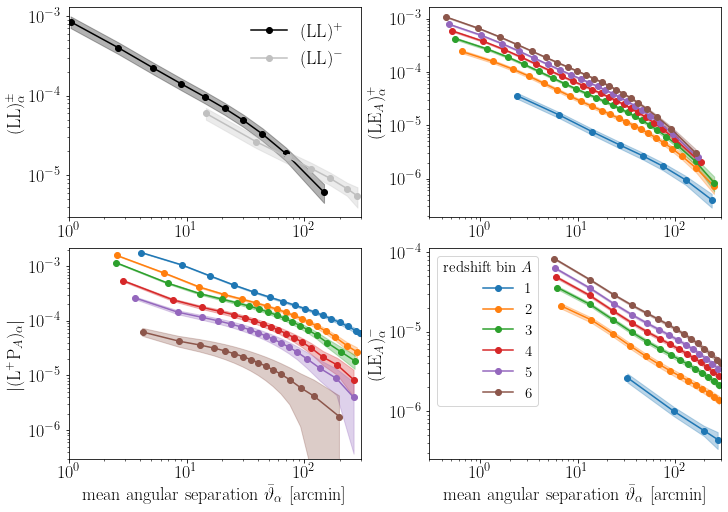

In [62]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 7),
                         sharex=False, sharey=False, constrained_layout=True)

# Structure of the plot
#
# LL LE+
# LP LE-

# Top-left panel: LL+ and LL-

ax = axes[0, 0]
corr = 'LL'
pms = ['plus', 'minus']
redshift = 0
colors = ['black', 'silver']
labels = [r'$({\rm LL})^+$', r'$({\rm LL})^-$']

for i, pm in enumerate(pms):

    # get angles
    Thetas = angular_distributions[f'{corr}_{pm}'].Thetas

    # get signal
    signal = np.abs(correlations_data[corr][pm + '_correlation'])

    # get uncertainty
    submatrix = extract_block(covmat, corr, corr)
    block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
    sigma = compute_variance(block, corr, pm, redshift)

    lower = signal - sigma
    upper = signal + sigma

    # plot
    color = colors[i]
    Thetas_arcmin = Thetas * 180/np.pi * 60
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.plot(Thetas_arcmin, signal,
            'o-', color=color, label=labels[i])
    ax.fill_between(Thetas_arcmin, lower, upper,
                    color=color, alpha=0.3)
    ax.set_xlim([1,300])

    # labels and legends
    ax.set_ylabel(r'$({\rm L}{\rm L})^\pm_\alpha$')
    ax.legend(frameon=False)

# Bottom-left panel: LP

ax = axes[1, 0]
corr = 'LP'
Nbin_z = Nbinz[corr]
cmap = plt.get_cmap('tab10')

for redshift in range(Nbin_z):

    # get angles
    Thetas = angular_distributions[corr][redshift].Thetas

    # get signal
    signal = np.abs(correlations_data[corr][redshift]['correlation'])

    # get uncertainty
    submatrix = extract_block(covmat, corr, corr)
    block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
    sigma = compute_variance(block, corr, pm, redshift)

    lower = signal - sigma
    upper = signal + sigma

    # plot
    color = cmap(redshift)
    Thetas_arcmin = Thetas * 180/np.pi * 60
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.plot(Thetas_arcmin, signal,
            'o-', color=color, label=f"{1+redshift}")
    ax.fill_between(Thetas_arcmin, lower, upper,
                    color=color, alpha=0.3)
    ax.set_xlim([1, 300])
    ax.set_ylim(ymin=3e-7)

    # labels and legends
    ax.set_xlabel(r'mean angular separation $\bar{\vartheta}_\alpha$ [arcmin]')
    ax.set_ylabel(r'$|({\rm L}^+ {\rm P}_A)_\alpha|$')

# right panels: LE

corr = 'LE'
Nbin_z = Nbinz[corr]
cmap = plt.get_cmap('tab10')
pms = ['plus', 'minus']
ylabels = [r'$({\rm L}{\rm E}_A)^+_\alpha$',
            r'$({\rm L}{\rm E}_A)^-_\alpha$']

for i, pm in enumerate(pms):

    ax = axes[i, 1]

    for redshift in range(Nbin_z):

        # get angles
        Thetas = angular_distributions[f'{corr}_{pm}'][redshift].Thetas

        # get signal
        signal = np.abs(correlations_data[corr][redshift][pm + '_correlation'])

        # get uncertainty
        submatrix = extract_block(covmat, corr, corr)
        block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
        sigma = compute_variance(block, corr, pm, redshift)

        lower = signal - sigma
        upper = signal + sigma

        # plot
        color = colors[i]
        Thetas_arcmin = Thetas * 180/np.pi * 60
        ax.set_xscale('log')
        ax.set_yscale('log')

        color = cmap(redshift)
        ax.plot(Thetas_arcmin, signal,
                'o-', color=color, label=f"{1+redshift}")
        ax.fill_between(Thetas_arcmin, lower, upper,
                        color=color, alpha=0.3)
        ax.set_xlim([0.3, 300])
        #ax.set_ylim(ymin=3e-7)

    # labels and legends
    ax.set_ylabel(ylabels[i])
    if i==1:
        ax.legend(
                title=r'redshift bin $A$',
                alignment='right',
                fontsize='small',
                title_fontsize='small',
                frameon=True)
        ax.set_xlabel(r'mean angular separation $\bar{\vartheta}_\alpha$ [arcmin]')
        

plt.savefig(path+'optimistic_all.pdf', bbox_inches='tight')
plt.show()

Plot the full covariance matrix

<ipython-input-63-3e588e7a9aed>:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


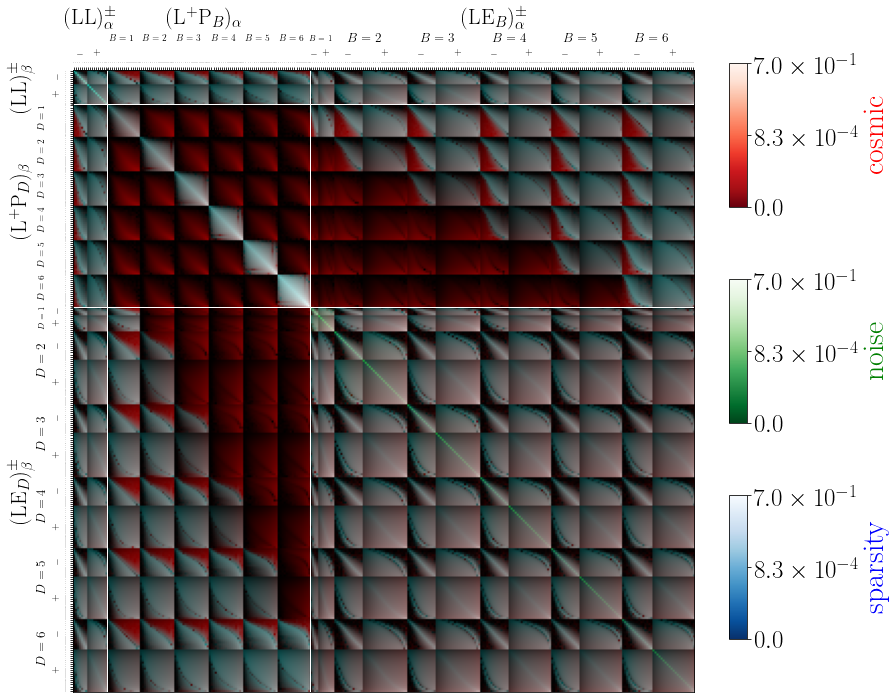

In [63]:
fig = plot_covariance(covariance_data, 
                              correlations_data, 
                              scale=True, 
                              normalize=True, 
                              log_scale=True, 
                              plot_colours = True,  #set to false to plot the total covariance
                              plot_noise = True,
                              plot_cosmic = True,
                              plot_sparsity = True,
                              eps = 1e-6, 
                              gamma = 1, 
                              eta = 1)

fig.tight_layout(rect=[0, 0, 0.9, 1])

#eps, gamma and eta change the contrast of the plot
#warning, if you change eta, then the numbers on the colourbars are no longer strictly true

# Show the plot
# fig.savefig(
    # f"Covariance_{nd['Nlens']}_sigL={nd['sigL']}.pdf",
    # bbox_inches='tight',
    # dpi=600 
# )

plt.savefig(path+'optimistic_covmat.pdf', bbox_inches='tight')
plt.show()

### B. Conservative scenario<a id='conservative'></a>
[Back to contents](#contents)

Define dataset

In [8]:
supply_binscheme = False

nd = {'Nlens': '1e4',    
      'sigL': '0.1',
      'Nbin_z': '1',
      'Nbina': '6',           #only used if supply_binscheme == True
      'SNR_goal': '8',       #only used if supply_binscheme == False
      'Nbin_max': '20',       #only used if supply_binscheme == False
      'nsamp': '1e6',
      'notes': ''
}

folder_name = "Nlens={}_sigL={}_Nbin_z={}_SNR_goal={}_Nbin_max={}_nsamp={}{}".format(
    nd['Nlens'], nd['sigL'], nd['Nbin_z'], nd['SNR_goal'], nd['Nbin_max'], nd['nsamp'], nd['notes'])

Read in distributions

In [9]:
#the file containing the redshift distributions
redshift_distributions = load_file(f"data/{folder_name}/redshift_distributions")

Nbinz_E = redshift_distributions["E"].Nbinz
Nbinz_P = redshift_distributions["P"].Nbinz

Nbinz = {'LP': Nbinz_P,
         'LE': Nbinz_E,
         'LL': 0
        }

#the file containing the angular distributions
angular_distributions = load_file(f"data/{folder_name}/angular_distributions")

#LL

Nbina_LL_plus = angular_distributions["LL_plus"].Nbina
Nbina_LL_minus = angular_distributions["LL_minus"].Nbina

Nbina_LL = [angular_distributions["LL_plus"].Nbina + angular_distributions["LL_minus"].Nbina]

#LE

Nbina_LE_plus = []
Nbina_LE_minus = []
Nbina_LE = []

for b in range(Nbinz_E):
    
    Nbina_LE_plus.append(angular_distributions["LE_plus"][b].Nbina)
    Nbina_LE_minus.append(angular_distributions["LE_minus"][b].Nbina)

    Nbina_LE.append(angular_distributions["LE_plus"][b].Nbina + angular_distributions["LE_minus"][b].Nbina)

#LP

Nbina_LP = []

for b in range(Nbinz_P):
    
    Nbina_LP.append(angular_distributions["LP"][b].Nbina)

#dictionaries to store the data

angular_bin_dictionary = {'LL': Nbina_LL,
                          'LE': Nbina_LE,
                          'LP': Nbina_LP
                        }

angular_bin_dictionary_pm = {'LL': {'plus': [Nbina_LL_plus], 'minus': [Nbina_LL_minus]},
                          'LE': {'plus': Nbina_LE_plus, 'minus': Nbina_LE_minus},
                          'LP': Nbina_LP
                        }

Read in correlations

In [10]:
correlations_data = read_correlations(folder_name)

Read in covariance

In [11]:
folder_structure = {
    "LLLL": 0,  # No redshift binning
    "LLLE": 1,  # 1 redshift bin index
    "LELE": 2,  # 2 redshift bin indices
    "LLLP": 1,  # 1 redshift bin index
    "LPLP": 2,  # 2 redshift bin indices
    "LELP": 2,  # 2 redshift bin indices
}

Nbinz_map = {
    "LE": Nbinz_E,
    "LP": Nbinz_P,
    "LL": 1,
}

covariance_data = read_all_matrices(folder_name)

Build the covariance matrix

In [12]:
noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
covmat = noise_mat + cosmic_mat + sparsity_mat

Define useful dictionaries

In [13]:
sizes = {'LL': angular_bin_dictionary['LL'][0],
 'LP': np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]),
 'LE': np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)])
    }

indices = {'LL': (0, sizes['LL']),
 'LP': (sizes['LL'], sizes['LL'] + sizes['LP']),
 'LE': (sizes['LL'] + sizes['LP'], sizes['LL'] + sizes['LP'] + sizes['LE'])
    }

correlation_names = {'LL': r'$\mathrm{LL}$',
 'LP': r'$\mathrm{LP}$',
 'LE': r'$\mathrm{LE}$'
    }

SNR for LL

In [14]:
corr = 'LL'
redshift = 0

print('In the conservative scenario:')

for pm in ['plus', 'minus']:

    # get signal
    signal  = correlations_data[corr][pm + '_correlation']
    
    # get uncertainty
    submatrix = extract_block(covmat, corr, corr)
    block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
    sigma = compute_variance(block, corr, pm, redshift)
    
    SNR = signal/sigma
    
    print('SNR of LL '+pm+' = {}'.format(SNR))

In the conservative scenario:
SNR of LL plus = [0.51974063]
SNR of LL minus = [0.51569347]


Plot the correlation functions with shaded error bars. In the conservative scenario LL is basically non-detectable, so we focus on LE and LP. Two graphs are enough since we choose to have no redshift binning.

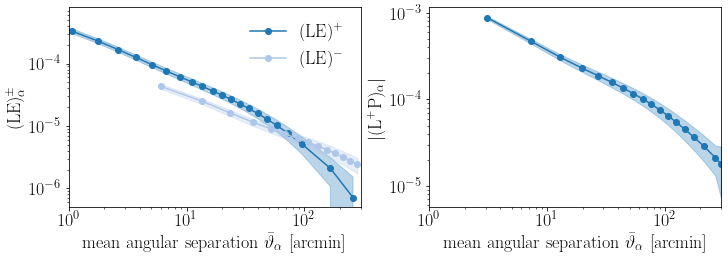

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3.5),
                         sharex=False, sharey=False, constrained_layout=True)

# Structure of the plot
#
# LE+/- LP

# Left panel: LE+ and LE-

ax = axes[0]
corr = 'LE'
pms = ['plus', 'minus']
redshift = 0
cmap = plt.get_cmap('tab20')
colors = [cmap(i) for i in range(2)]
labels = [r'$({\rm LE})^+$', r'$({\rm LE})^-$']

for i, pm in enumerate(pms):

    # get angles
    Thetas = angular_distributions[f'{corr}_{pm}'][redshift].Thetas

    # get signal
    signal = np.abs(correlations_data[corr][redshift][pm + '_correlation'])

    # get uncertainty
    submatrix = extract_block(covmat, corr, corr)
    block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
    sigma = compute_variance(block, corr, pm, redshift)

    lower = signal - sigma
    upper = signal + sigma

    # plot
    color = colors[i]
    Thetas_arcmin = Thetas * 180/np.pi * 60
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.plot(Thetas_arcmin, signal,
            'o-', color=color, label=labels[i])
    ax.fill_between(Thetas_arcmin, lower, upper,
                    color=color, alpha=0.3)
    ax.set_xlim([1,300])

    # labels and legends
    ax.set_xlabel(r'mean angular separation $\bar{\vartheta}_\alpha$ [arcmin]')
    ax.set_ylabel(r'$({\rm L}{\rm E})^\pm_\alpha$')
    ax.legend(frameon=False)

    
# Right panel: LP

ax = axes[1]
corr = 'LP'
Nbin_z = Nbinz[corr]
#cmap = plt.get_cmap('tab10')

for redshift in range(Nbin_z):

    # get angles
    Thetas = angular_distributions[corr][redshift].Thetas

    # get signal
    signal = np.abs(correlations_data[corr][redshift]['correlation'])

    # get uncertainty
    submatrix = extract_block(covmat, corr, corr)
    block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
    sigma = compute_variance(block, corr, pm, redshift)

    lower = signal - sigma
    upper = signal + sigma

    # plot
    color = cmap(redshift)
    Thetas_arcmin = Thetas * 180/np.pi * 60
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.plot(Thetas_arcmin, signal,
            'o-', color=color, label=f"{1+redshift}")
    ax.fill_between(Thetas_arcmin, lower, upper,
                    color=color, alpha=0.3)
    ax.set_xlim([1, 300])
    #ax.set_ylim(ymin=3e-7)

    # labels and legends
    ax.set_xlabel(r'mean angular separation $\bar{\vartheta}_\alpha$ [arcmin]')
    ax.set_ylabel(r'$|({\rm L}^+ {\rm P})_\alpha|$')
        

plt.savefig(path+'conservative_LE_LP.pdf', bbox_inches='tight')
plt.show()

Plot the full covariance matrix

<ipython-input-18-ae2ae02c08e2>:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


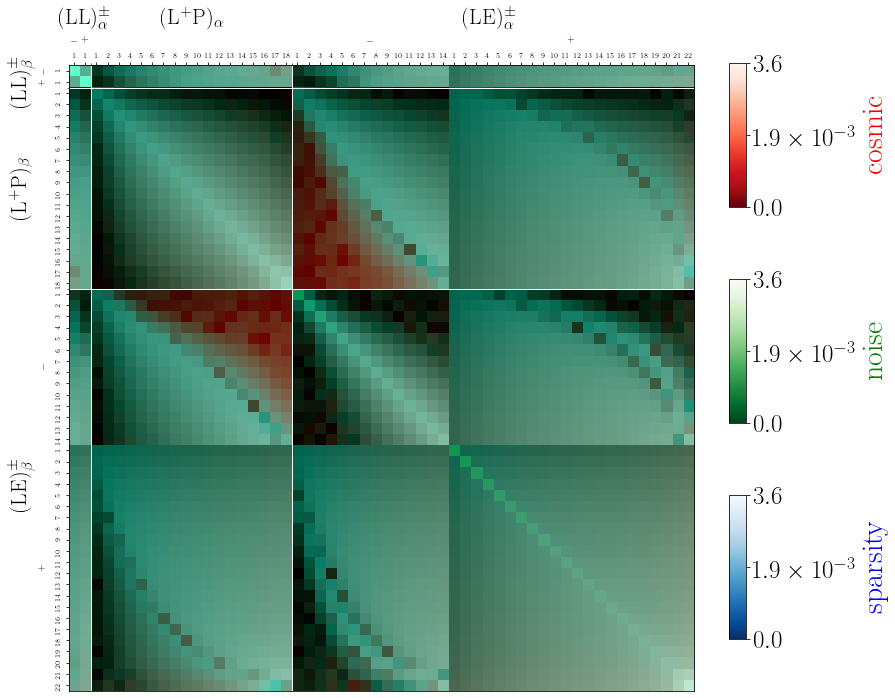

In [18]:
fig = plot_covariance(covariance_data, 
                      correlations_data, 
                      scale = True, 
                      normalize = True, 
                      log_scale = True, 
                      plot_colours = True,  #set to false to plot the total covariance
                      plot_noise = True,
                      plot_cosmic = True,
                      plot_sparsity = True,
                      redshift_binning = False,
                      eps = 1e-6, 
                      gamma = 1, 
                      eta = 1)

fig.tight_layout(rect=[0, 0, 0.9, 1])

#eps, gamma and eta change the contrast of the plot
#warning, if you change eta, then the numbers on the colourbars are no longer strictly true

#plt.savefig(path+'conservative_covmat.pdf', bbox_inches='tight')
plt.show()